In [ ]:
setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/bulk/GTEx/cortex")

library(dplyr)

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/marker_vs_mod_corr.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/module_projection_fxns.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor



Attaching package: ‘qvalue’


The following object is masked from ‘package:WGCNA’:

    qvalue


Loading required package: future


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


The following objects are masked from ‘package:data.table’:

    dcast, melt




In [5]:
# Trying another approach to get top cell type modules

In [2]:
summary_type <- "PC1"

In [3]:
marker_genes_list <- readRDS("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/marker_genes/AI/Claude_cortical_markers_human.RDS")

bulk_expr <- fread("data/cleaned/TopModPosBC/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned.csv", data.table=FALSE)

network_dir <- "GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules"

In [5]:
colnames(bulk_expr)[1] <- "Gene"

mean_expr <- data.frame(
    Index=1:nrow(bulk_expr), 
    Gene=bulk_expr[,1], 
    Expr=rowMeans(bulk_expr[,-1])
)

mean_expr <- mean_expr %>%
    group_by(Gene) %>%
    slice_max(Expr, with_ties=FALSE)

bulk_expr <- bulk_expr[mean_expr$Index,]

marker_genes_list <- lapply(marker_genes_list, function(markers) {
    markers[markers %in% bulk_expr[,1]]
})

In [6]:
networks <- list.files(network_dir, pattern="signum", full.names=TRUE)
networks <- networks[lengths(lapply(networks, list.files)) > 0]

In [7]:
# Make sure order of samples matches FM output

modEigs <- fread(list.files(networks[1], pattern="eigen", full.names=TRUE), data.table=FALSE)
bulk_expr <- bulk_expr[,c(1, match(modEigs$Sample, colnames(bulk_expr)))]
all.equal(modEigs$Sample, colnames(bulk_expr)[-1])

[1] TRUE

In [ ]:
# Get cell type modules: 
# Find module that is most correlated with PC1 for marker genes
# Get kME for all genes for that module; are cell type marker genes significantly overrepresented at the top of that list? 

ctype_mod_corrs <- marker_vs_mod_corr(bulk_expr, networks,  marker_genes_list, summary_type)

In [9]:
ctype_mod_corrs %>%
    group_by(Cell_type) %>%
    slice_max(Corr) %>%
    slice_min(padj) %>%
    arrange(padj) %>%
    filter(padj < .05)

Cell_type,Network,Mod,Corr,Top_kME_genes,ME_path,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
All GABAergic,Bicor-None_signum0.415_minSize8_merge_ME_0.85_19747,cyan,0.9781438,"GAD1, GAD2, DLX1, DLX6, NXPH2, LHX6, LGI2, CNR1, MYO5B, SLC32A1, DLX2, PTHLH, PNOC, TACR1, DCX",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.415_minSize8_merge_ME_0.85_19747/Module_eigengenes_06-00-33.csv,All GABAergic,7.282942e-21,7.282942e-21,1.1778933,0.9997688,2.069886,7,"GAD1, GAD2, DLX1, DLX6, SLC32A1, DLX2, DLX5"
All Neuronal,Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747,brown,0.9462106,"SLC17A7, ENO2, SNHG14, STMN2, KCNC1, TUBGCP5, GLCE, C1orf74, CRYM, CERK, INCENP, CACNB2, SYT1, SATB2, CASC15",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747/Module_eigengenes_06-52-41.csv,All Neuronal,5.506360e-16,5.506360e-16,1.0276699,0.9947978,1.955551,9,"ENO2, STMN2, SYT1, THY1, TUBB3, SNAP25, RBFOX3, NRGN, MAP2"
OPC,Bicor-None_signum0.363_minSize6_merge_ME_0.85_19747,lightyellow,0.9681777,"MYT1, PCDH15, STK32A, DISC1, BLM, PDGFRA, VCAN, MPZL1, WSCD1, CACNG4, BCAN, INAVA, B3GNT7, SCUBE2, SAPCD2",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.363_minSize6_merge_ME_0.85_19747/Module_eigengenes_07-44-53.csv,OPC,8.180076e-16,8.180076e-16,1.0276699,0.9910749,1.981105,11,"PCDH15, PDGFRA, VCAN, BCAN, OLIG1, PTPRZ1, OLIG2, CSPG4, GPR17, NKX2-2, SOX10"
Oligo,Bicor-None_signum0.438_minSize10_merge_ME_0.85_19747,purple,0.9474018,"MOG, CNP, SLC45A3, TJAP1, PHLDB1, DBNDD2, TTYH2, ENSG00000261329, TMC6, PLEKHG3, CNTN2, MAG, FA2H, CLDN11, LIPE",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.438_minSize10_merge_ME_0.85_19747/Module_eigengenes_05-36-13.csv,Oligo,1.429859e-13,1.429859e-13,0.9436322,0.9761378,2.021850,13,"MOG, CNP, MAG, FA2H, CLDN11, TF, KLK6, OPALIN, PLP1, ERMN, MOBP, MBP"
Micro/PVM,Bicor-None_signum0.349_minSize8_merge_ME_0.85_19747,purple,0.9781593,"BTK, TYROBP, ITGAM, CD74, BIN2, DOCK2, HLA-DOA, HLA-DRA, CSF1R, TFEC, LILRB4, SLC7A7, HLA-DMB, CD37, DEF6",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.349_minSize8_merge_ME_0.85_19747/Module_eigengenes_08-57-33.csv,Micro/PVM,2.095514e-12,2.095514e-12,0.8986712,0.9604338,1.970830,16,"TYROBP, ITGAM, CSF1R, C1QA, TMEM119, SPI1, AIF1, CTSS, C1QC, TREM2, C1QB, CX3CR1, SELPLG, P2RY12, SALL1, HEXB"
Endo,Bicor-None_signum0.349_minSize6_merge_ME_0.85_19747,greenyellow,0.9178545,"ESAM, PRKCH, SHE, MECOM, APOL3, SLC2A1, MMRN2, ACVRL1, NAALADL1, TCN2, HLA-E, MYO1C, PALMD, CLEC14A, ABCB1",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.349_minSize6_merge_ME_0.85_19747/Module_eigengenes_08-33-26.csv,Endo,3.170164e-10,3.170164e-10,0.8140358,0.9802086,1.978095,9,"VWF, CLDN5, NOSTRIN, PECAM1, EMCN, FLT1, ITM2A, TEK, BSG"
VLMC,Bicor-None_signum0.438_minSize6_merge_ME_0.85_19747,sienna3,0.9018366,"FOXC2, FOXD2, WFDC21P, BNC2, COL1A2, PTGDR, AOX1, CLIC6, FOXD2-AS1, SIX2, BMP5, ENSG00000287881, LINC01139, PRDM6, ITGBL1",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.438_minSize6_merge_ME_0.85_19747/Module_eigengenes_05-11-03.csv,VLMC,1.169264e-09,1.169264e-09,0.7881868,0.9749996,2.259019,11,"COL1A2, COL1A1, OGN, COL3A1, PTGDS, DCN, SLC6A13, LUM"
Astro,Bicor-None_signum0.438_minSize10_merge_ME_0.85_19747,brown,0.94796

In [11]:
top_mods_df <- ctype_mod_corrs %>%
    group_by(Cell_type) %>%
    slice_max(Corr) %>%
    slice_min(padj) %>%
    arrange(padj) %>%
    filter(padj < .05)

In [ ]:
fwrite(top_mods_df, file=paste0("data/enrichments/", network_dir, "_top_corr_enriched_w_Claude_marker_genes_", summary_type, "_top_Qval_mods.csv"), row.names=FALSE)

#### Check for conflicting enrichments in top cell type modules:

In [ ]:
ctype <- "VLMC"
network = top_mods_df$Network[top_mods_df$Cell_type == ctype] 
mod = top_mods_df$Mod[top_mods_df$Cell_type == ctype]

mask <- ctype_mod_corrs$Network == network & ctype_mod_corrs$Mod == mod
ctype_mod_corrs[mask,] %>%
    filter(padj < .05)

In [12]:
ctype <- "All Neuronal"
network = top_mods_df$Network[top_mods_df$Cell_type == ctype] 
mod = top_mods_df$Mod[top_mods_df$Cell_type == ctype]

mask <- ctype_mod_corrs$Network == network & ctype_mod_corrs$Mod == mod
ctype_mod_corrs[mask,] %>%
    filter(padj < .05)

,Cell_type,Network,Mod,Corr,Top_kME_genes,ME_path,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
brown8,All Neuronal,Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747,brown,0.9462106,"SLC17A7, ENO2, SNHG14, STMN2, KCNC1, TUBGCP5, GLCE, C1orf74, CRYM, CERK, INCENP, CACNB2, SYT1, SATB2, CASC15",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747/Module_eigengenes_06-52-41.csv,All Neuronal,5.506360e-16,5.506360e-16,1.0276699,0.9947978,1.955551,9,"ENO2, STMN2, SYT1, THY1, TUBB3, SNAP25, RBFOX3, NRGN, MAP2"
brown81,All Glutamatergic,Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747,brown,0.9380530,"SLC17A7, ENO2, SNHG14, STMN2, KCNC1, TUBGCP5, GLCE, C1orf74, CRYM, CERK, INCENP, CACNB2, SYT1, SATB2, CASC15",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747/Module_eigengenes_06-52-41.csv,All Glutamatergic,2.055008e-07,2.055008e-07,0.6901325,0.9634930,1.842793,8,"SLC17A7, SATB2, EMX1, NEUROD6, CAMK2A, TBR1, NEUROD2, SLC17A6"
brown22,L4 IT,Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747,brown,0.8527101,"SLC17A7, ENO2, SNHG14, STMN2, KCNC1, TUBGCP5, GLCE, C1orf74, CRYM, CERK, INCENP, CACNB2, SYT1, SATB2, CASC15",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747/Module_eigengenes_06-52-41.csv,L4 IT,1.877458e-02,1.877458e-02,0.3524879,0.8249613,1.565168,6,"COL5A2, CTXN3, RORB, THSD7A, RSPO1"
brown82,Chandelier,Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747,brown,0.9093171,"SLC17A7, ENO2, SNHG14, STMN2, KCNC1, TUBGCP5, GLCE, C1orf74, CRYM, CERK, INCENP, CACNB2, SYT1, SATB2, CASC15",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.395_minSize10_merge_ME_0.85_19747/Module_eigengenes_06-52-41.csv,Chandelier,3.496503e-02,3.496503e-02,0.2413400,0.7924846,1.507557,6,"SNHG14, CPNE5, PVALB, VIPR2, NOS1, UNC5B"


In [13]:
ctype <- "All Glutamatergic"
network = top_mods_df$Network[top_mods_df$Cell_type == ctype] 
mod = top_mods_df$Mod[top_mods_df$Cell_type == ctype]

mask <- ctype_mod_corrs$Network == network & ctype_mod_corrs$Mod == mod
ctype_mod_corrs[mask,] %>%
    filter(padj < .05)

,Cell_type,Network,Mod,Corr,Top_kME_genes,ME_path,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
blue,All Neuronal,Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747,blue,0.9330768,"ENO2, KCNC1, SNHG14, SLC17A7, TUBGCP5, SATB2, THY1, TNFRSF11A, GLCE, CRYM, EMX1, RBFOX3, CPNE5, VLDLR, INCENP",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747/Module_eigengenes_09-14-33.csv,All Neuronal,7.814300e-09,7.814300e-09,0.7477397,0.9696423,1.910912,9,"ENO2, THY1, RBFOX3, NRGN, STMN2, TUBB3, SYT1, SNAP25, MAP2"
blue6,All Glutamatergic,Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747,blue,0.9384606,"ENO2, KCNC1, SNHG14, SLC17A7, TUBGCP5, SATB2, THY1, TNFRSF11A, GLCE, CRYM, EMX1, RBFOX3, CPNE5, VLDLR, INCENP",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747/Module_eigengenes_09-14-33.csv,All Glutamatergic,9.805086e-08,9.805086e-08,0.7049757,0.9657588,1.852909,8,"SLC17A7, SATB2, EMX1, TBR1, CAMK2A, NEUROD6, NEUROD2, SLC17A6"
blue7,L4 IT,Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747,blue,0.8542282,"ENO2, KCNC1, SNHG14, SLC17A7, TUBGCP5, SATB2, THY1, TNFRSF11A, GLCE, CRYM, EMX1, RBFOX3, CPNE5, VLDLR, INCENP",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747/Module_eigengenes_09-14-33.csv,L4 IT,2.688505e-02,2.688505e-02,0.3524879,0.8130344,1.554303,6,"COL5A2, CTXN3, RORB, THSD7A, RSPO1"
blue8,Chandelier,Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747,blue,0.9315038,"ENO2, KCNC1, SNHG14, SLC17A7, TUBGCP5, SATB2, THY1, TNFRSF11A, GLCE, CRYM, EMX1, RBFOX3, CPNE5, VLDLR, INCENP",GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules/Bicor-None_signum0.349_minSize10_merge_ME_0.85_19747/Module_eigengenes_09-14-33.csv,Chandelier,3.796204e-02,3.796204e-02,0.2311267,0.7912101,1.516912,6,"SNHG14, CPNE5, PVALB, VIPR2, UNC5B, NOS1"


In [ ]:
ctype <- "L2/3 IT"
network = top_mods_df$Network[top_mods_df$Cell_type == ctype] 
mod = top_mods_df$Mod[top_mods_df$Cell_type == ctype]

mask <- ctype_mod_corrs$Network == network & ctype_mod_corrs$Mod == mod
ctype_mod_corrs[mask,] %>%
    filter(padj < .05)

#### Save MEs

In [ ]:
modEig_list <- lapply(1:nrow(top_mods_df), function(i) {
    modEig <- fread(top_mods_df$ME_path[i], data.table=FALSE)
    col_idx <- which(colnames(modEig) == top_mods_df$Mod[i]) 
    modEig <- modEig[,c(1, col_idx)]
    colnames(modEig)[2] <- top_mods_df$Cell_type[i]
    modEig 
})

modEig_df <- Reduce(function(x, y) merge(x, y, by="Sample"), modEig_list)

In [ ]:
fwrite(modEig_df, file=paste0("data/ctype_abundance/", network_dir, "_top_corr_enriched_w_Claude_marker_genes_", summary_type, "_ctype_abundance.csv"), row.names=FALSE)

#### Plot projections

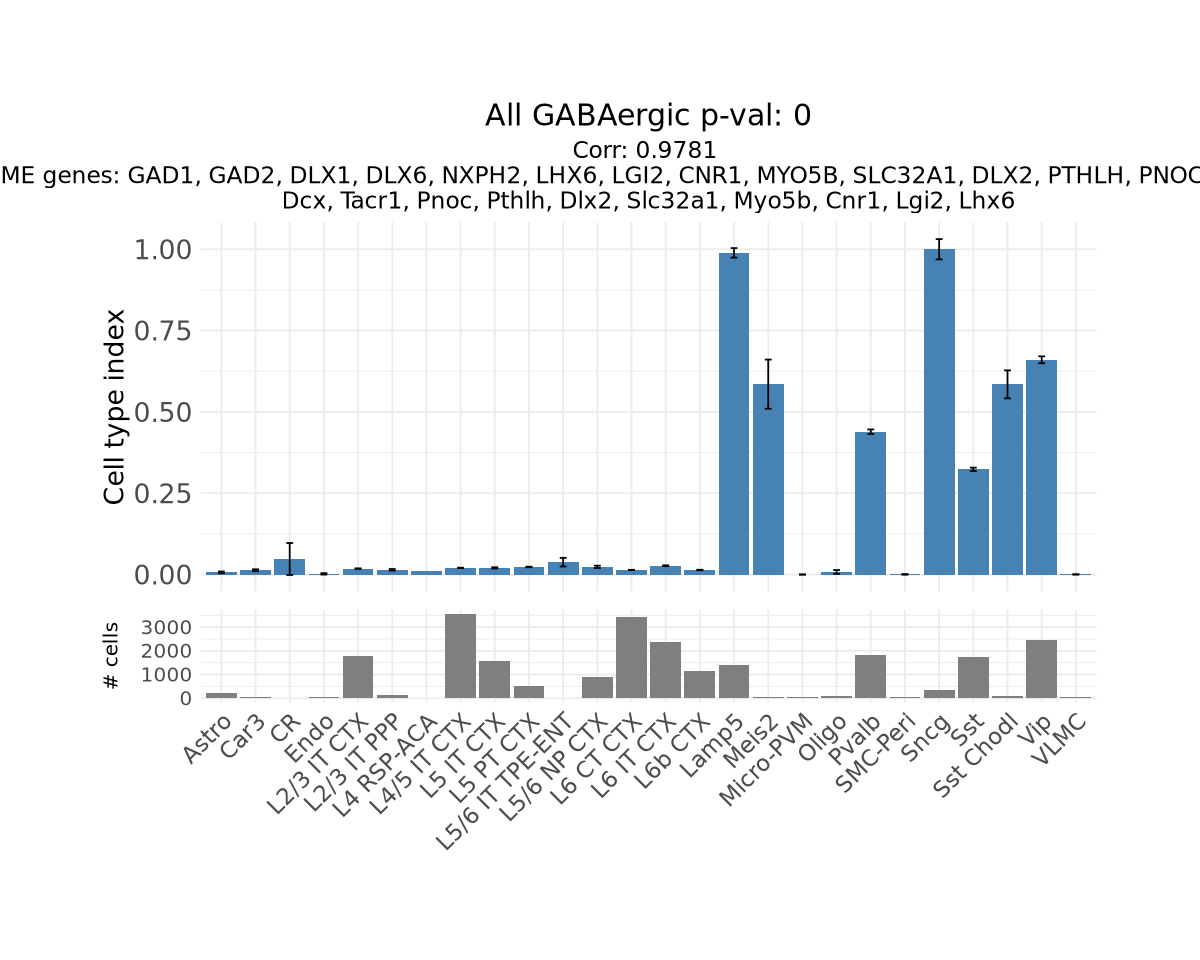

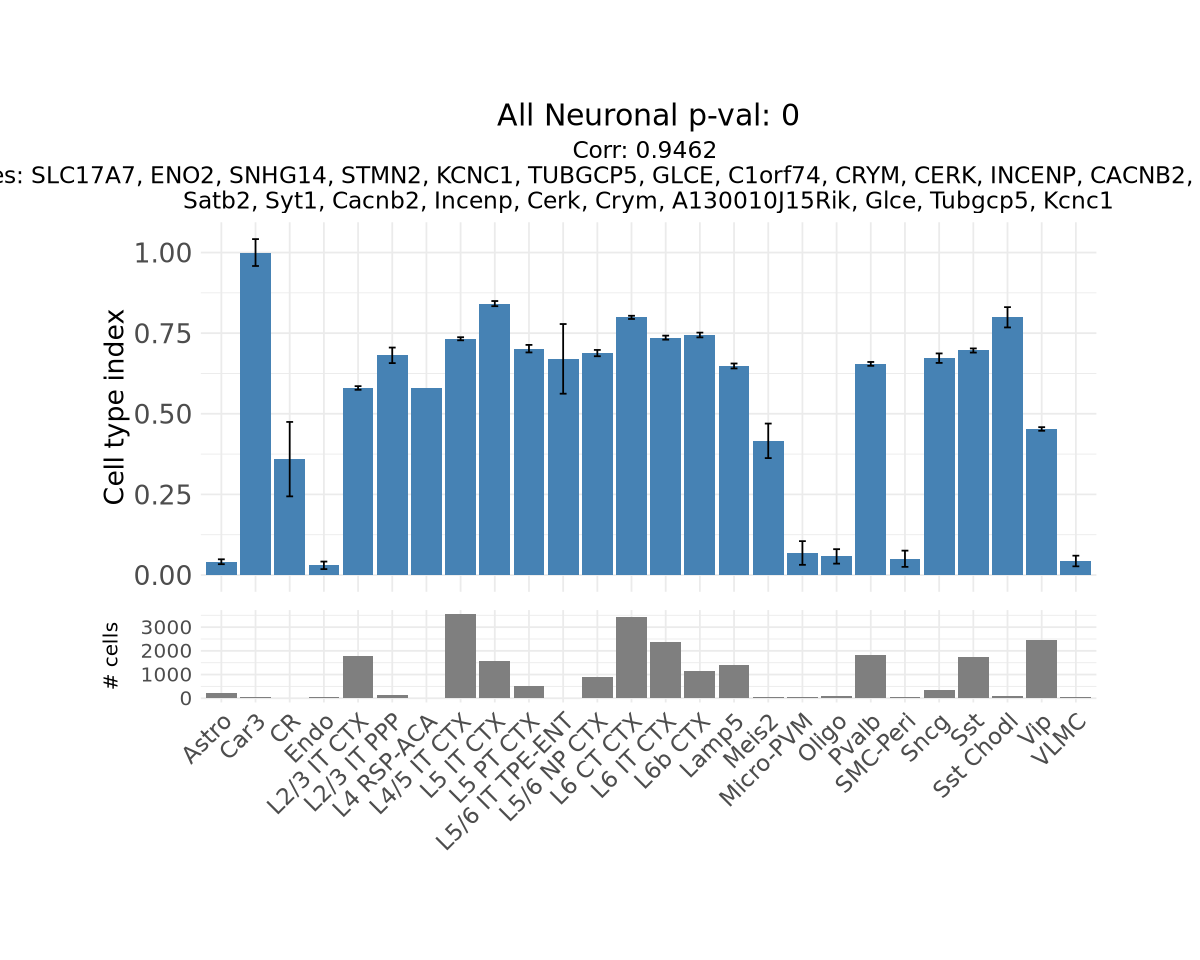

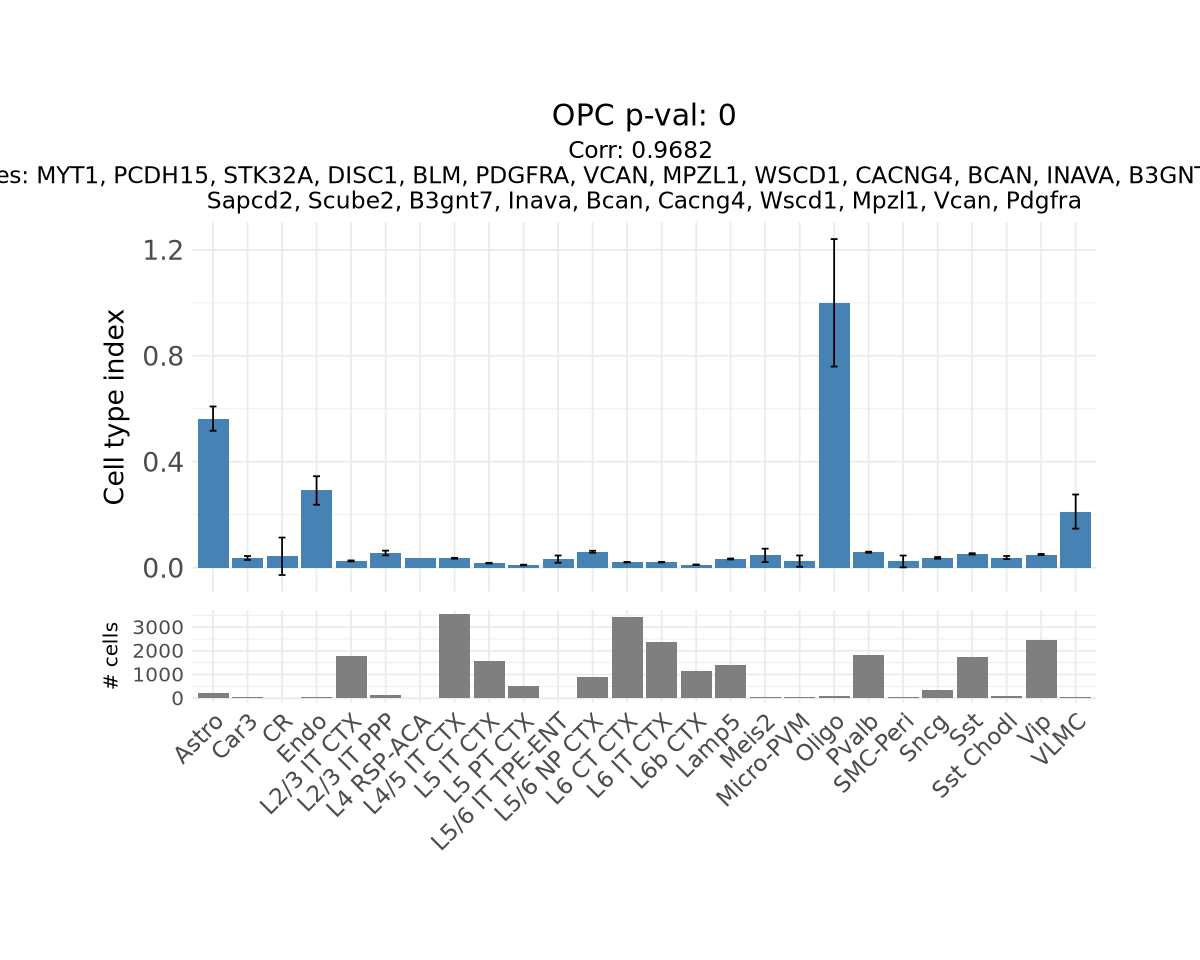

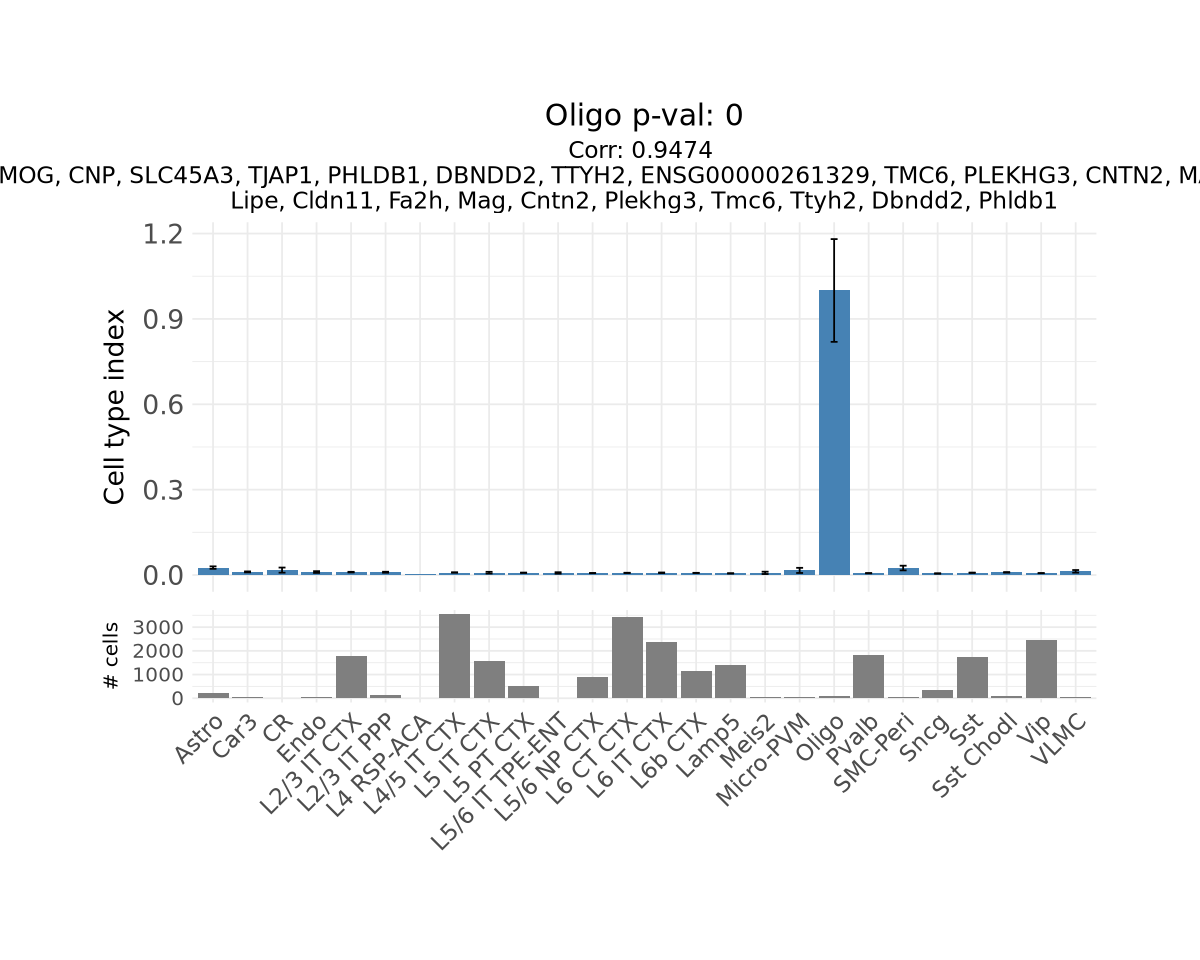

Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `DB.Class.Key == class_key & Common.Organism.Name == "mouse,
  laboratory"`.
Caused by warning in `DB.Class.Key == class_key`:
! longer object length is not a multiple of shorter object length”


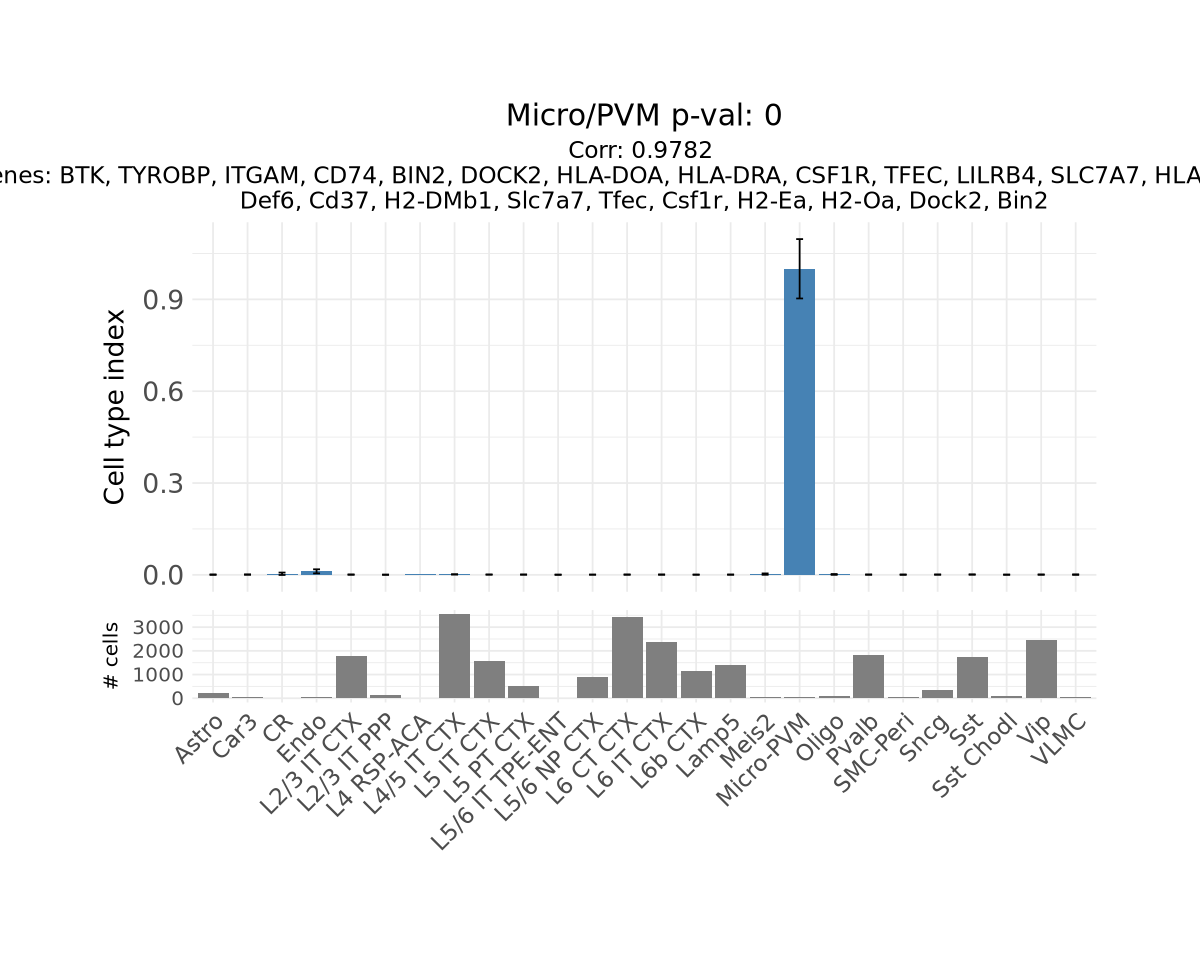

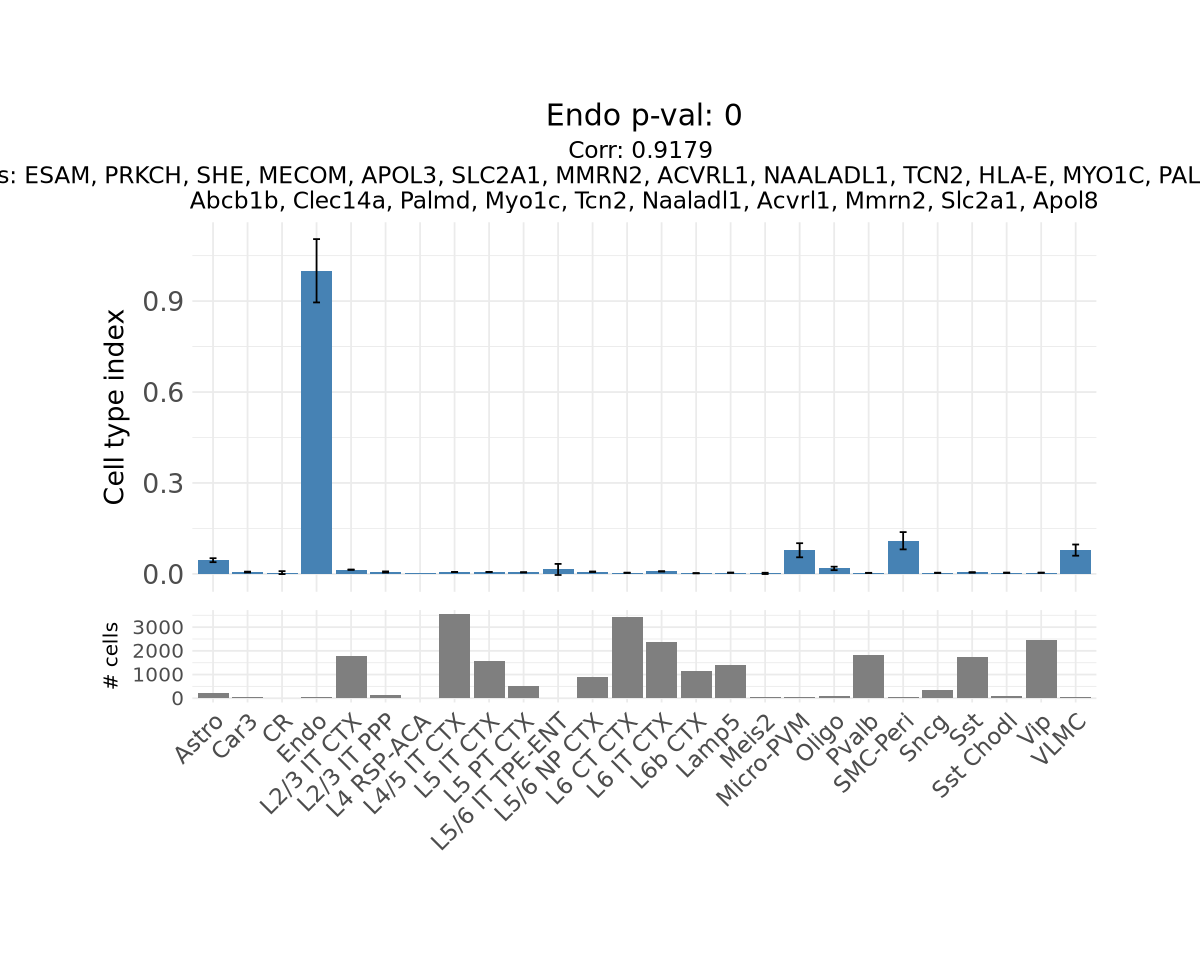

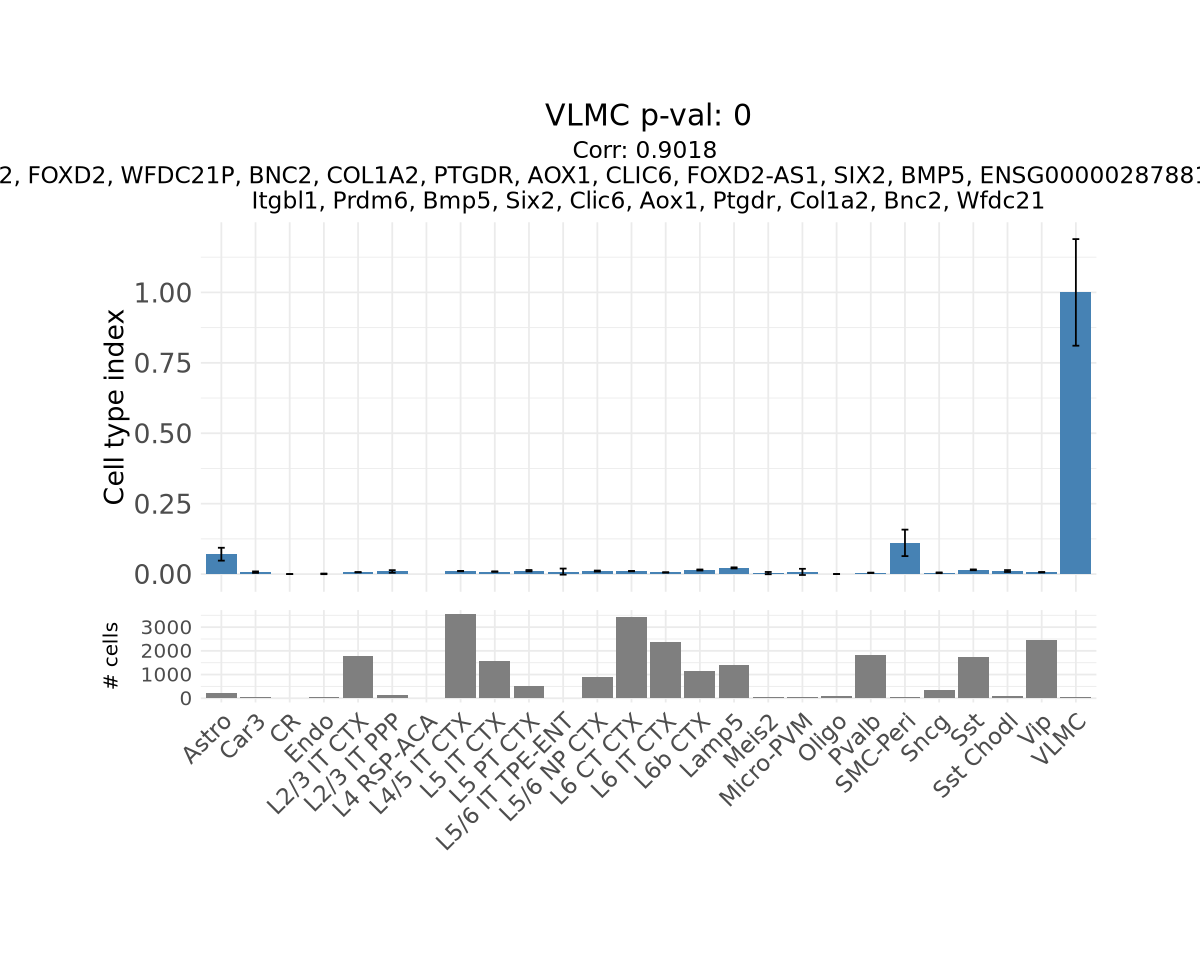

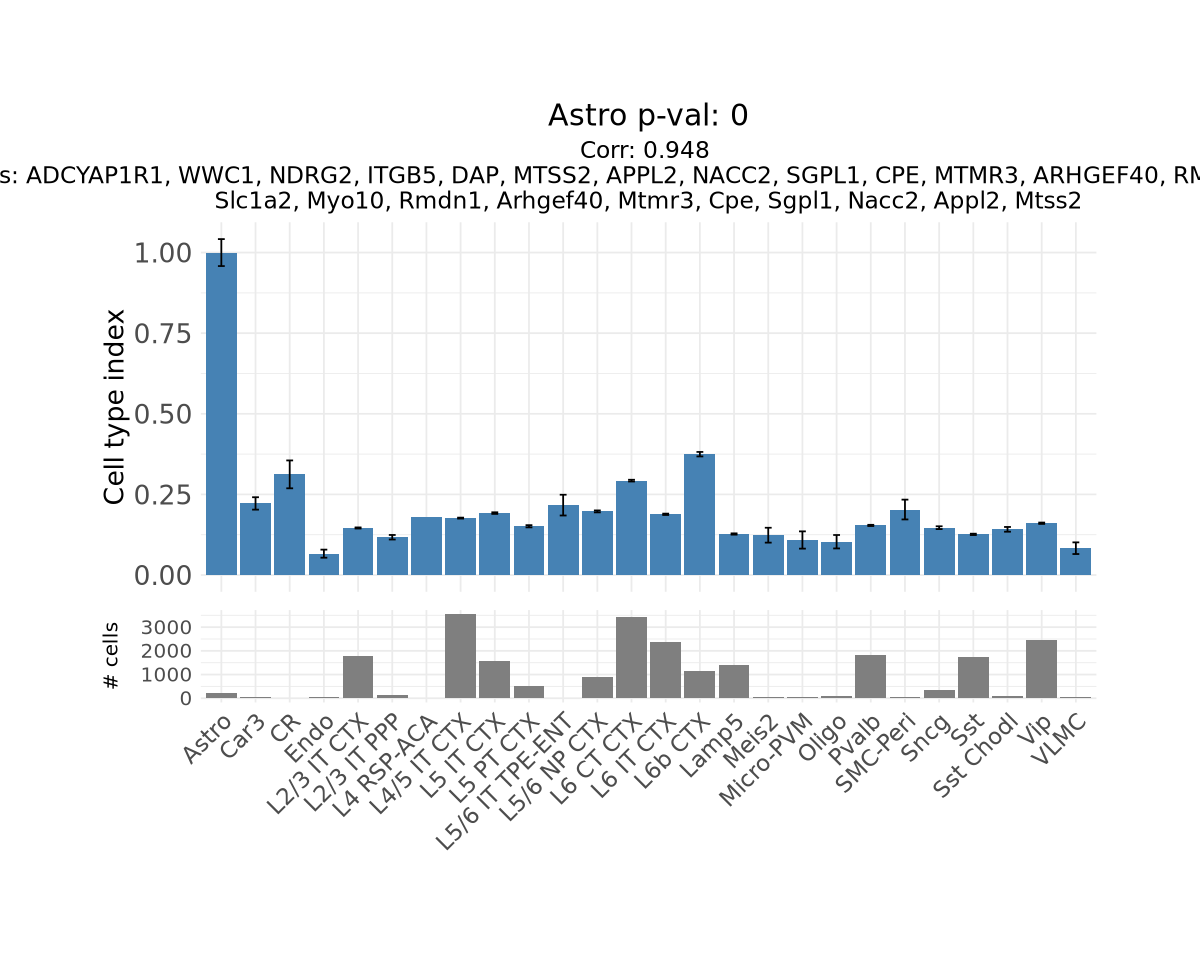

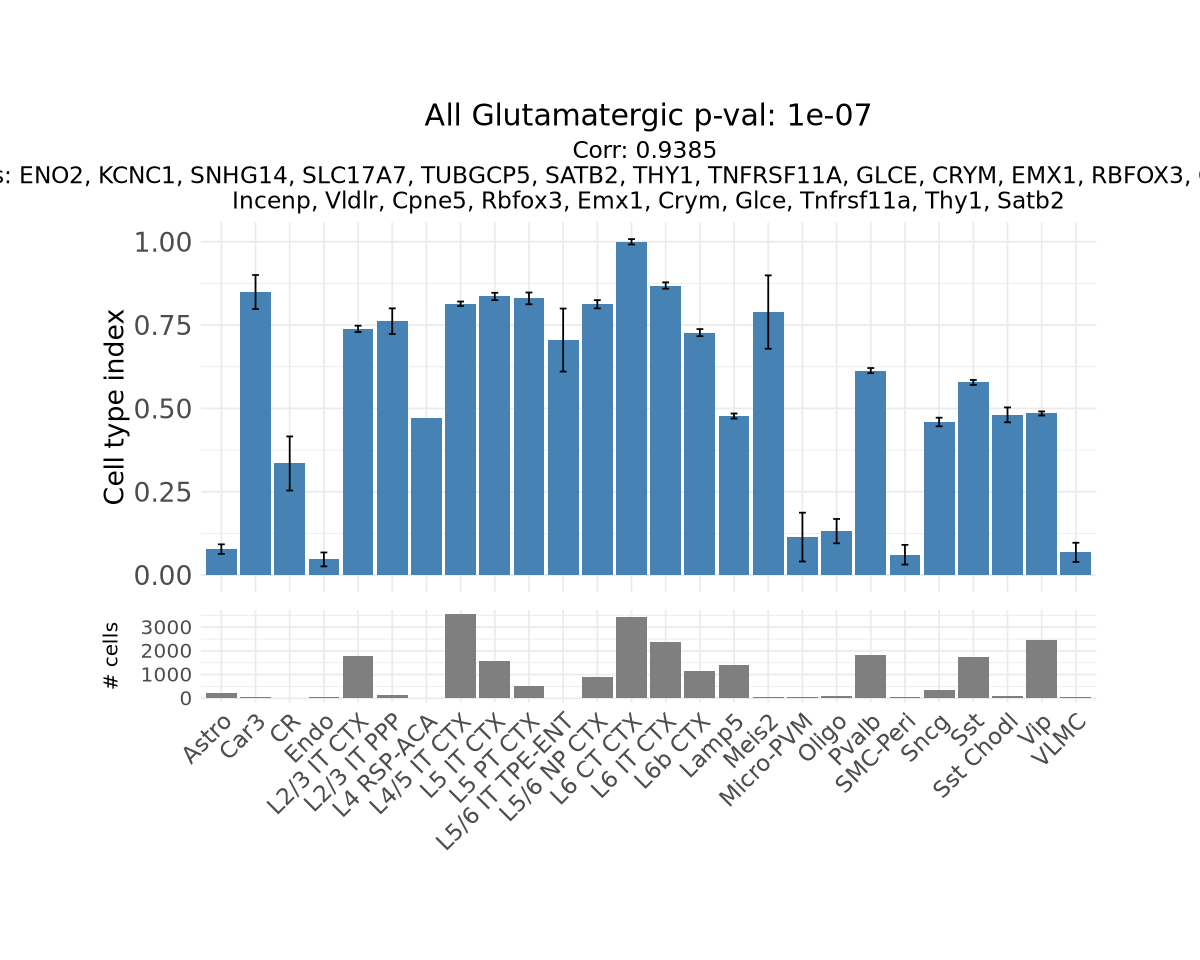

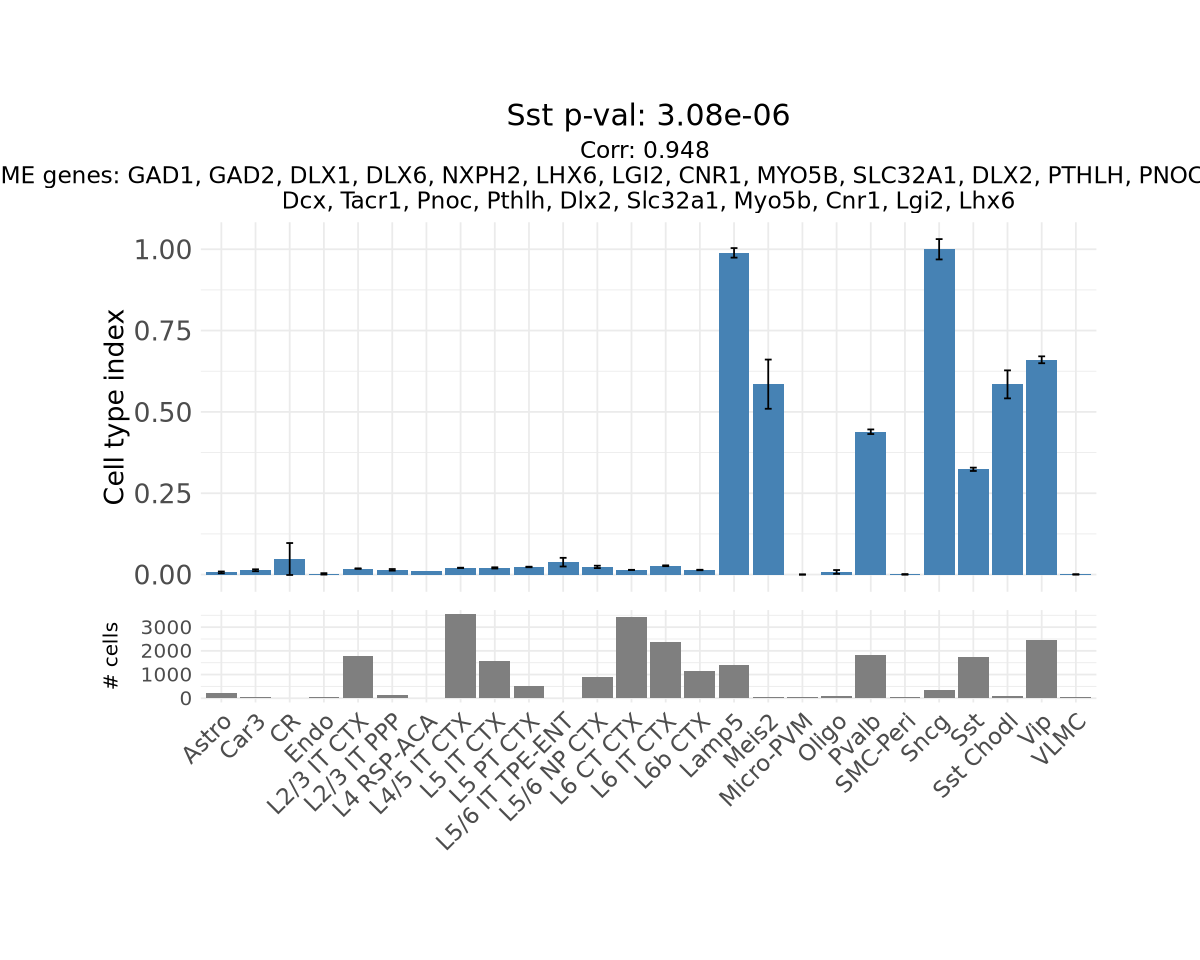

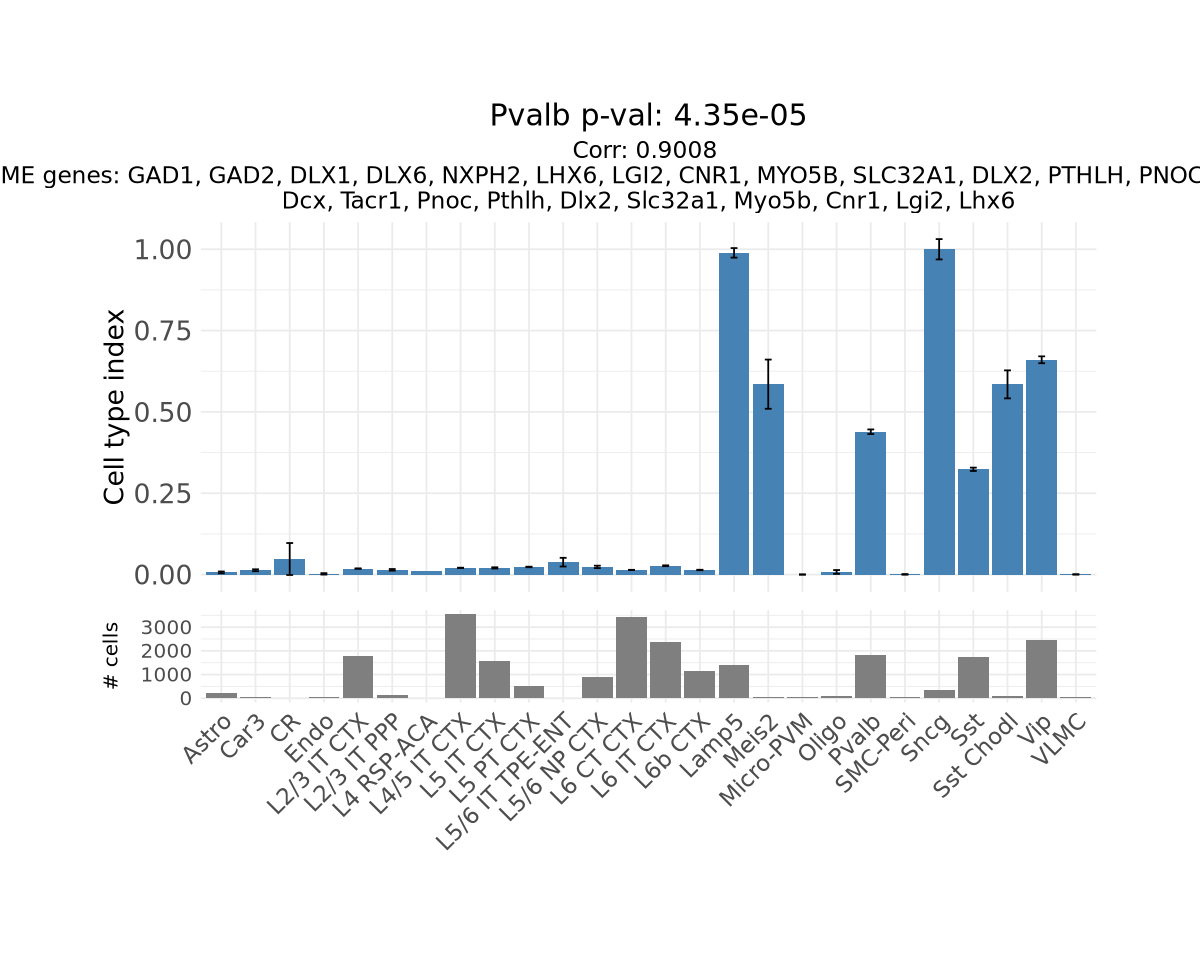

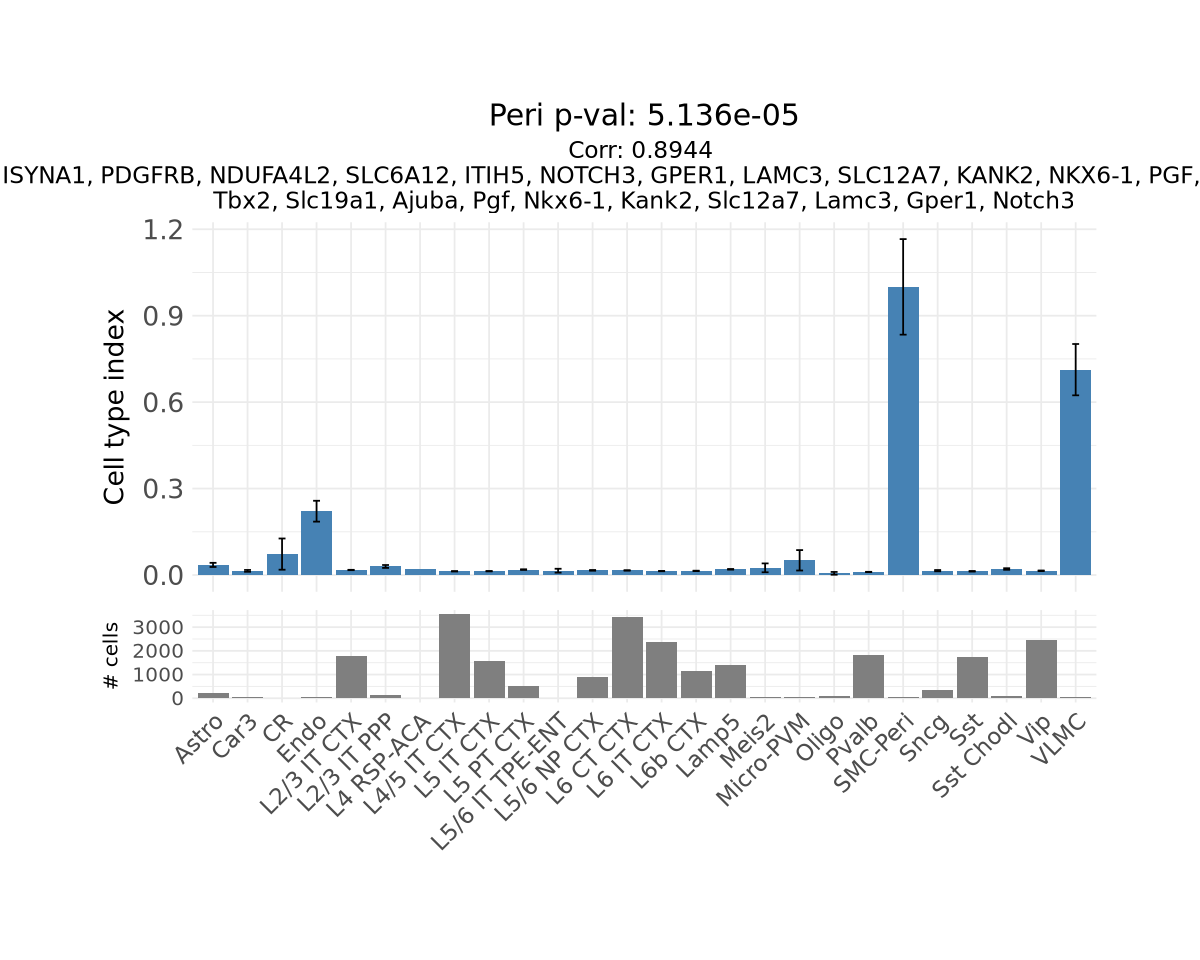

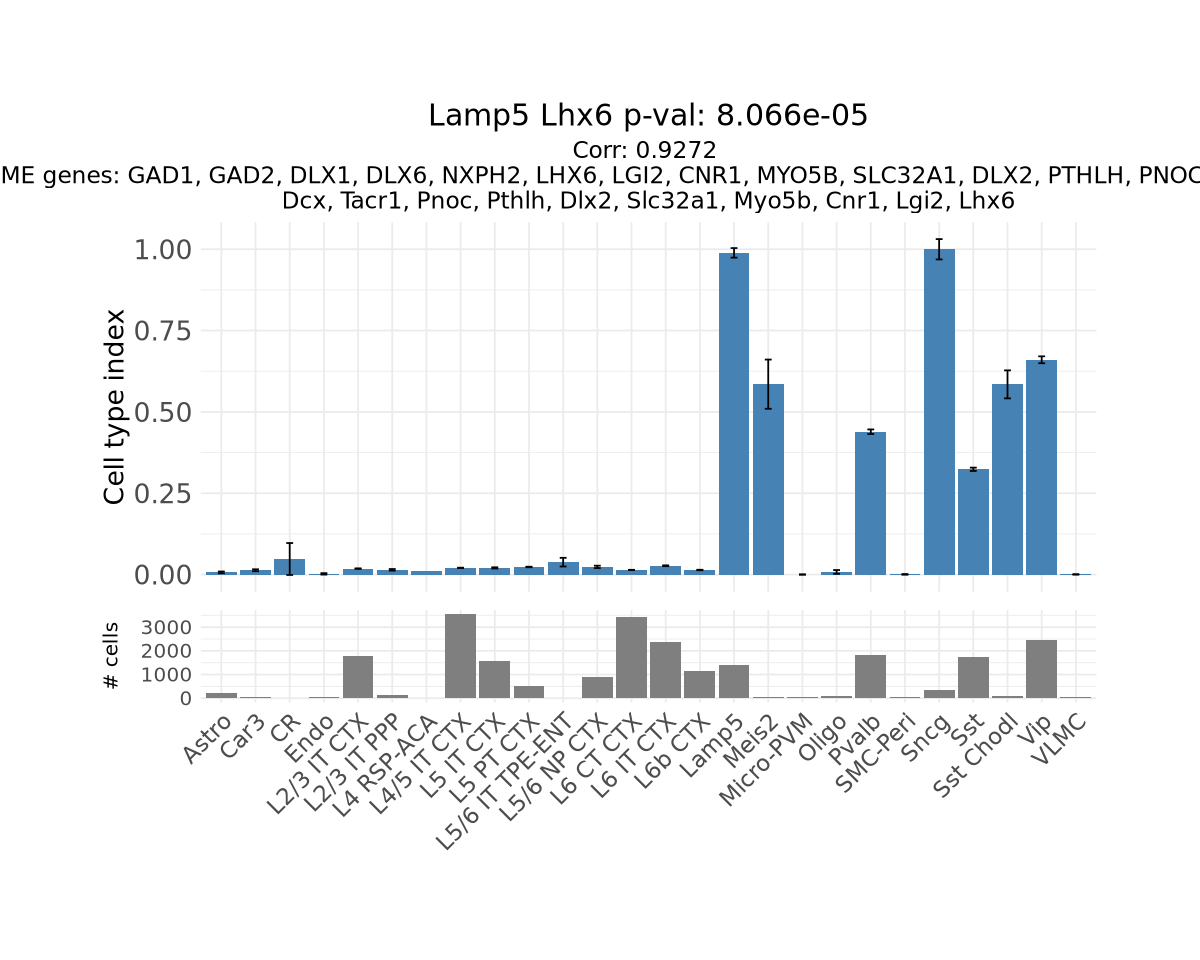

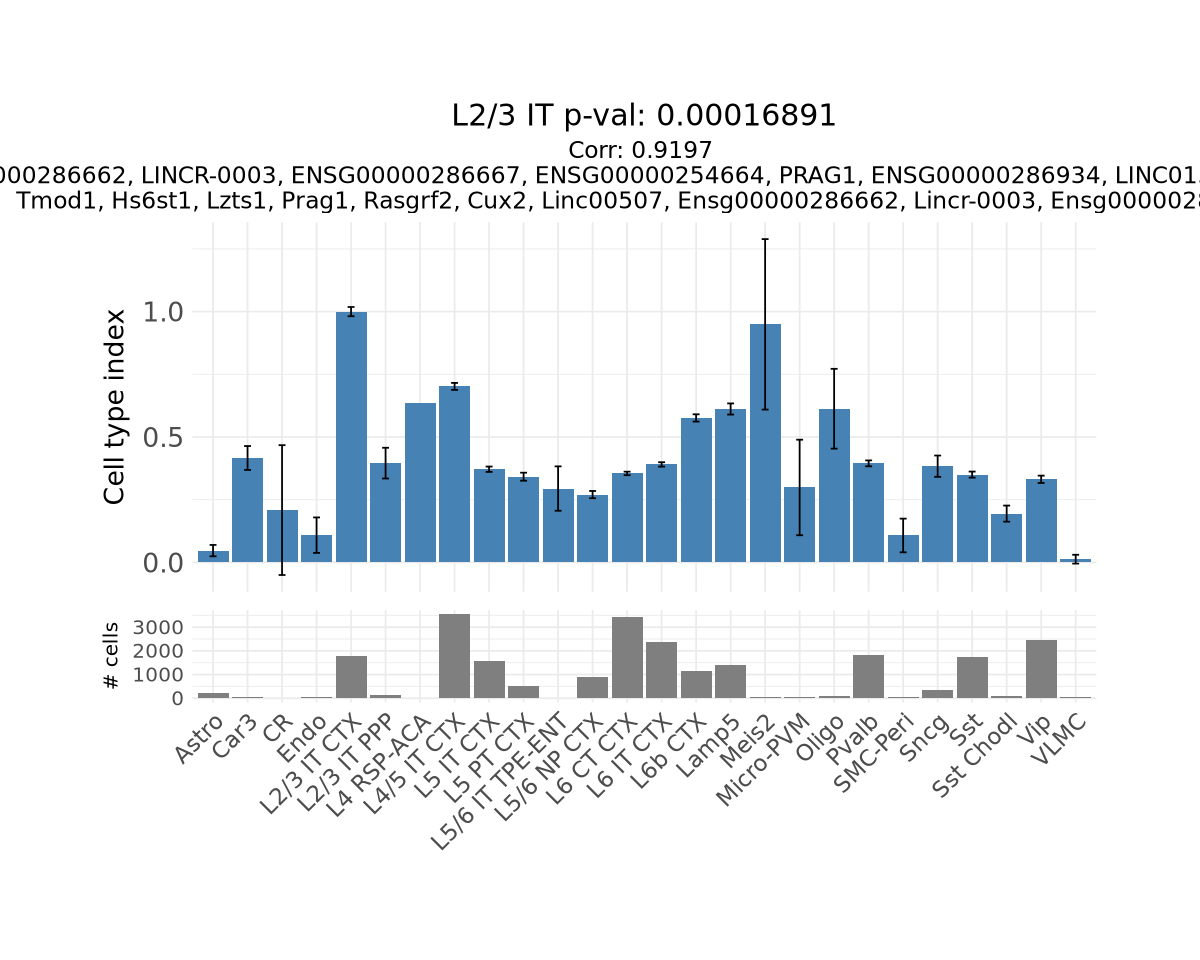

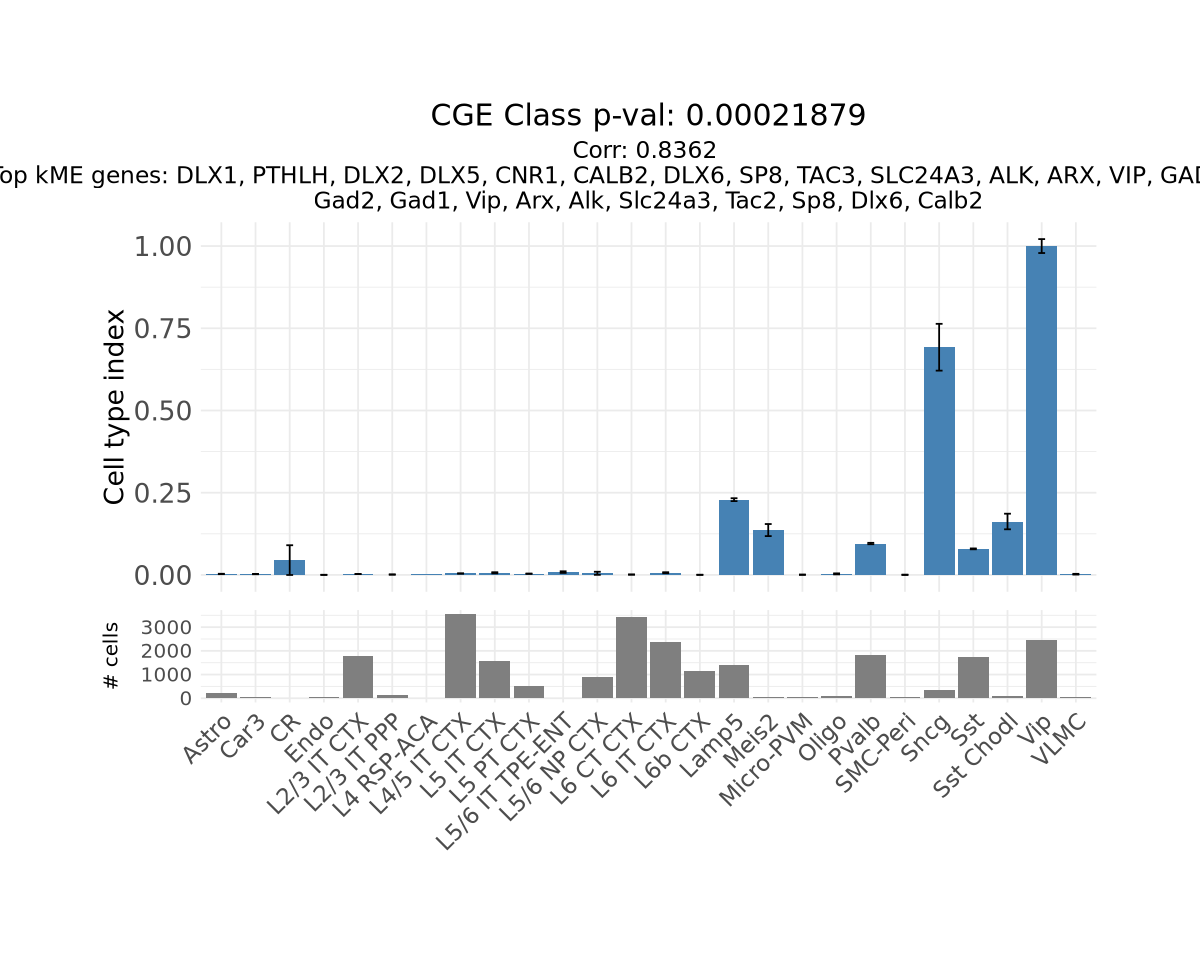

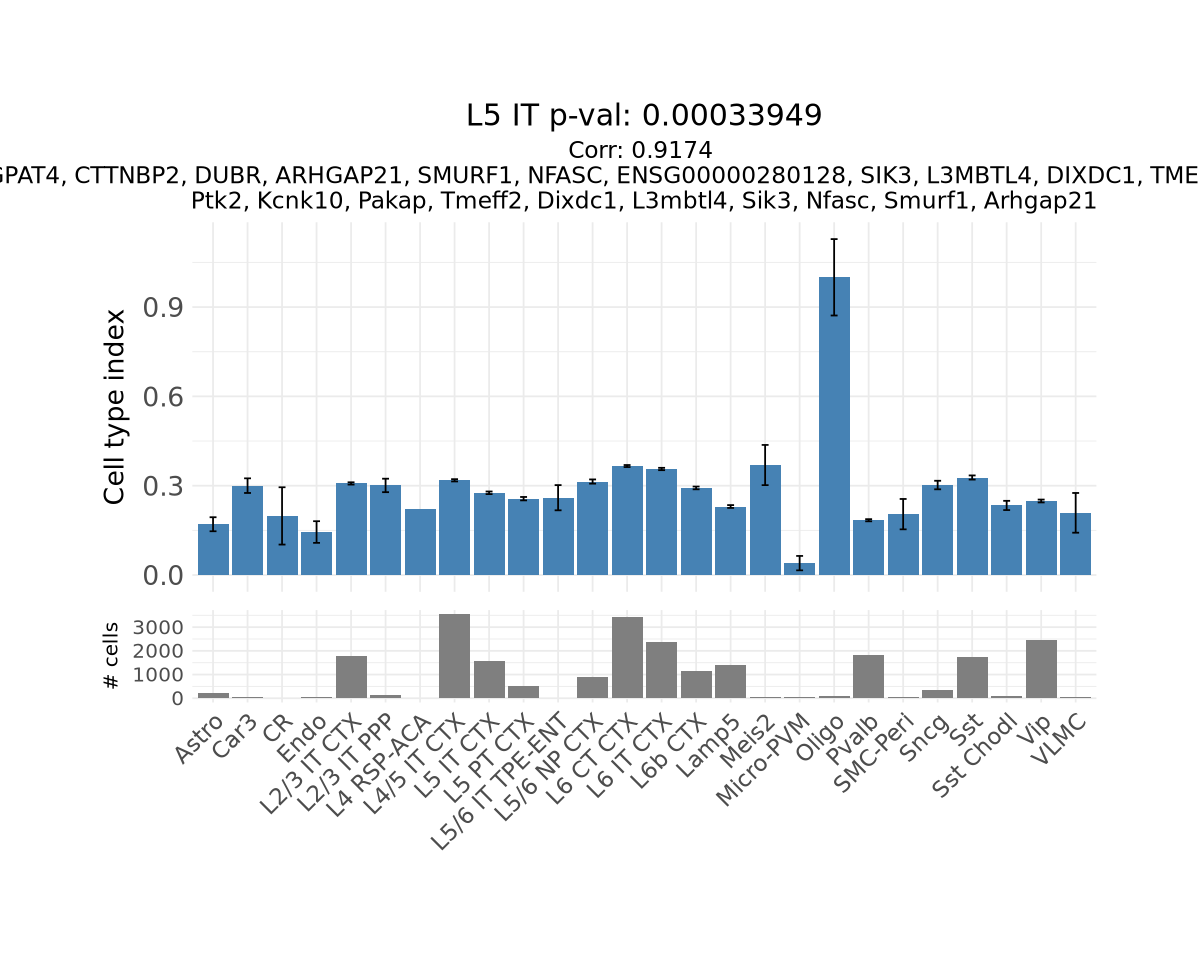

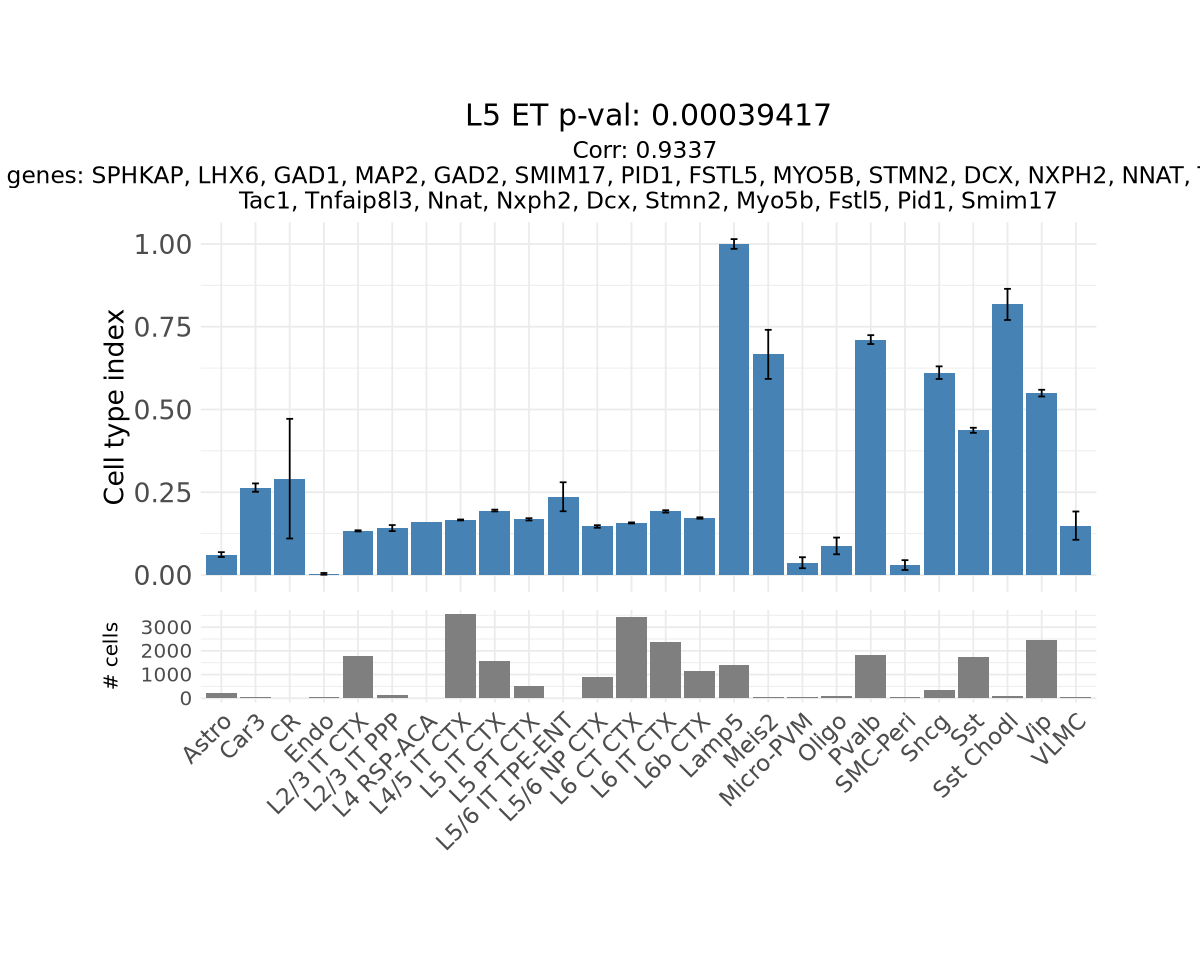

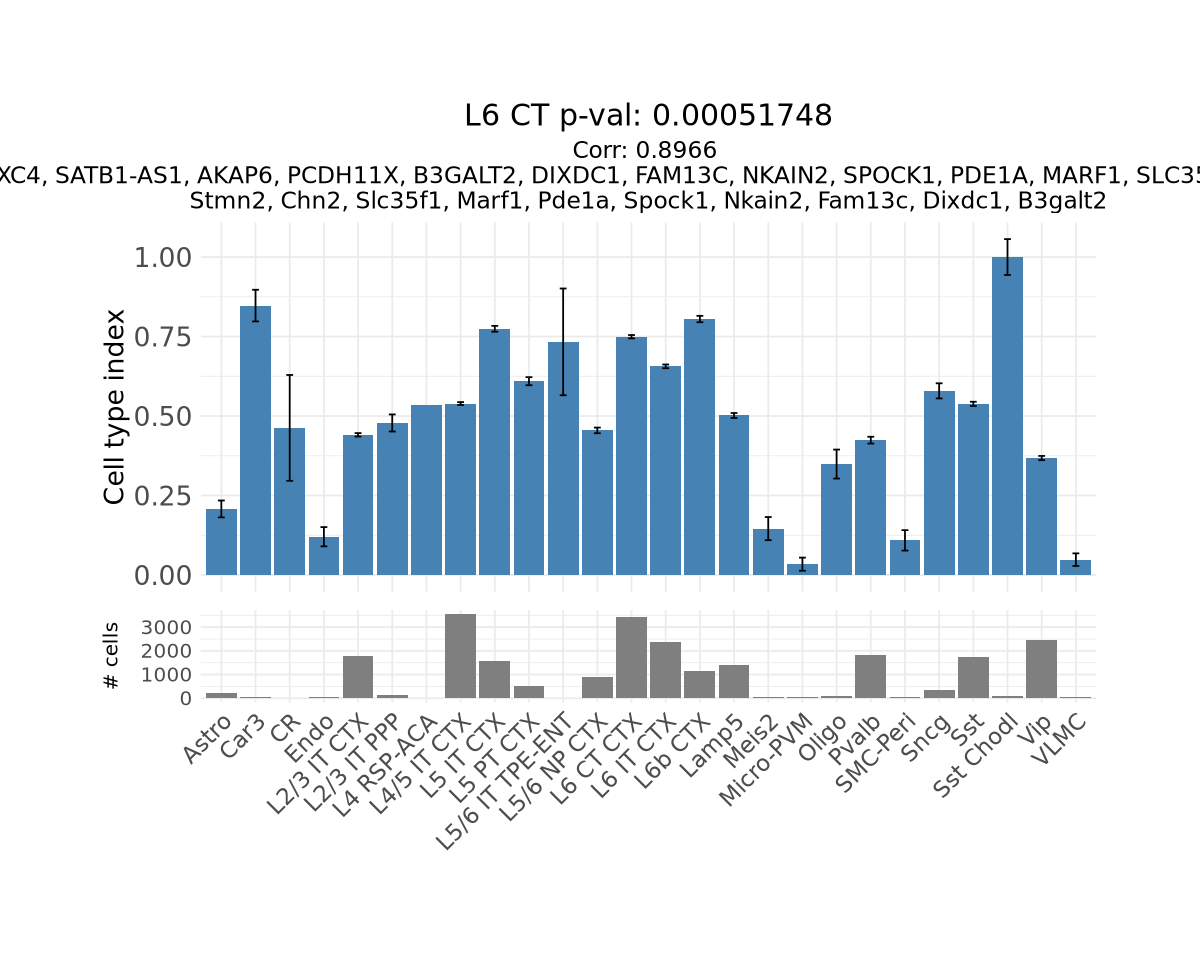

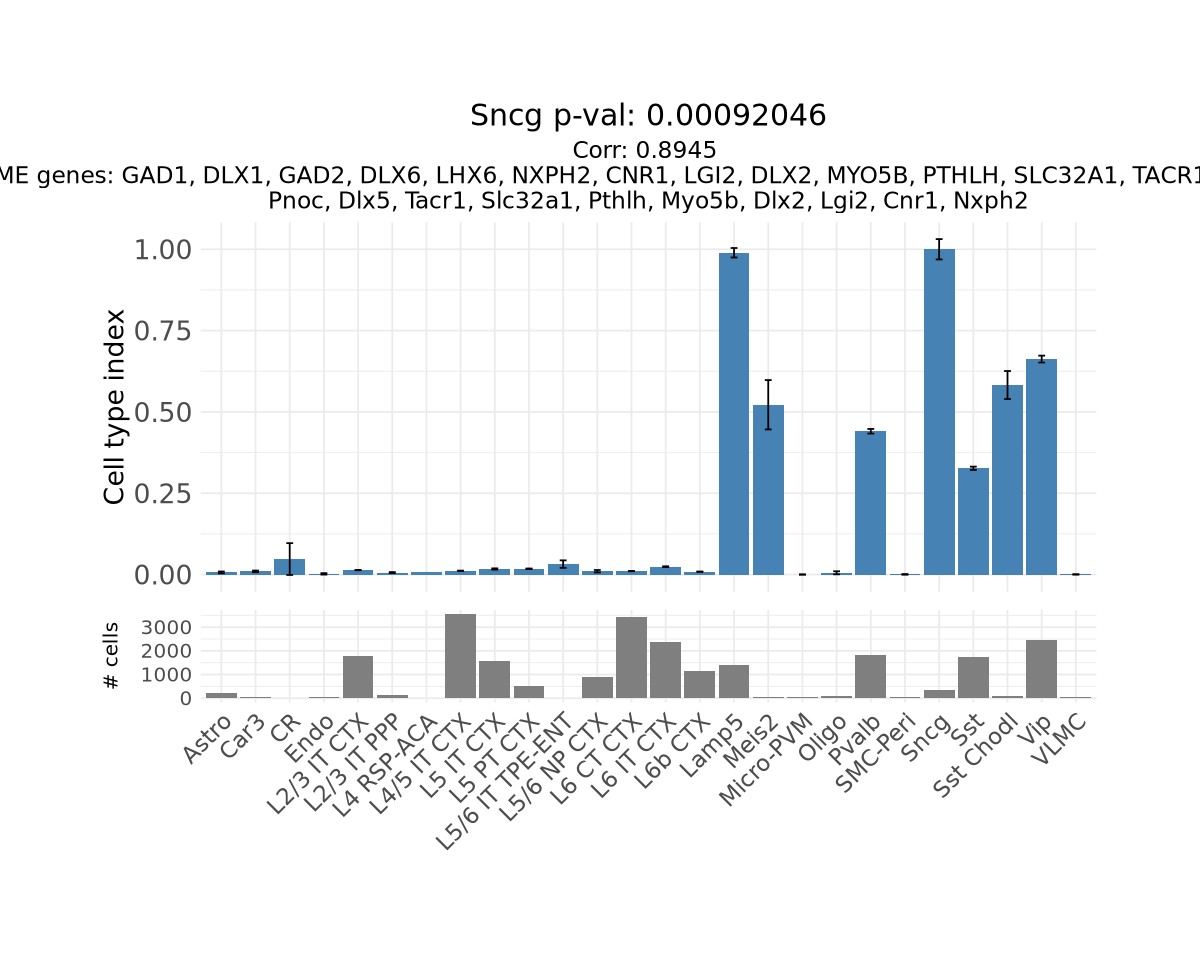

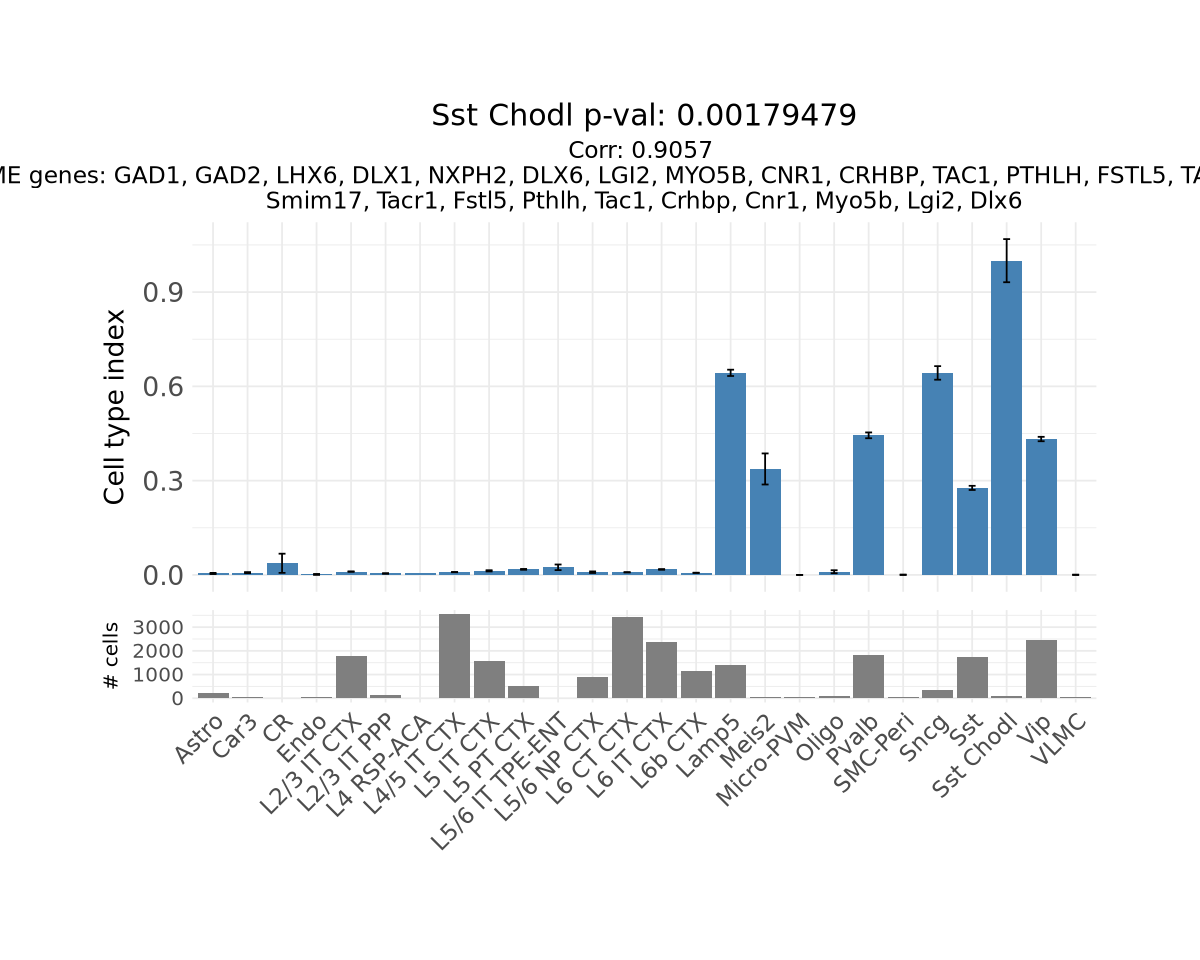

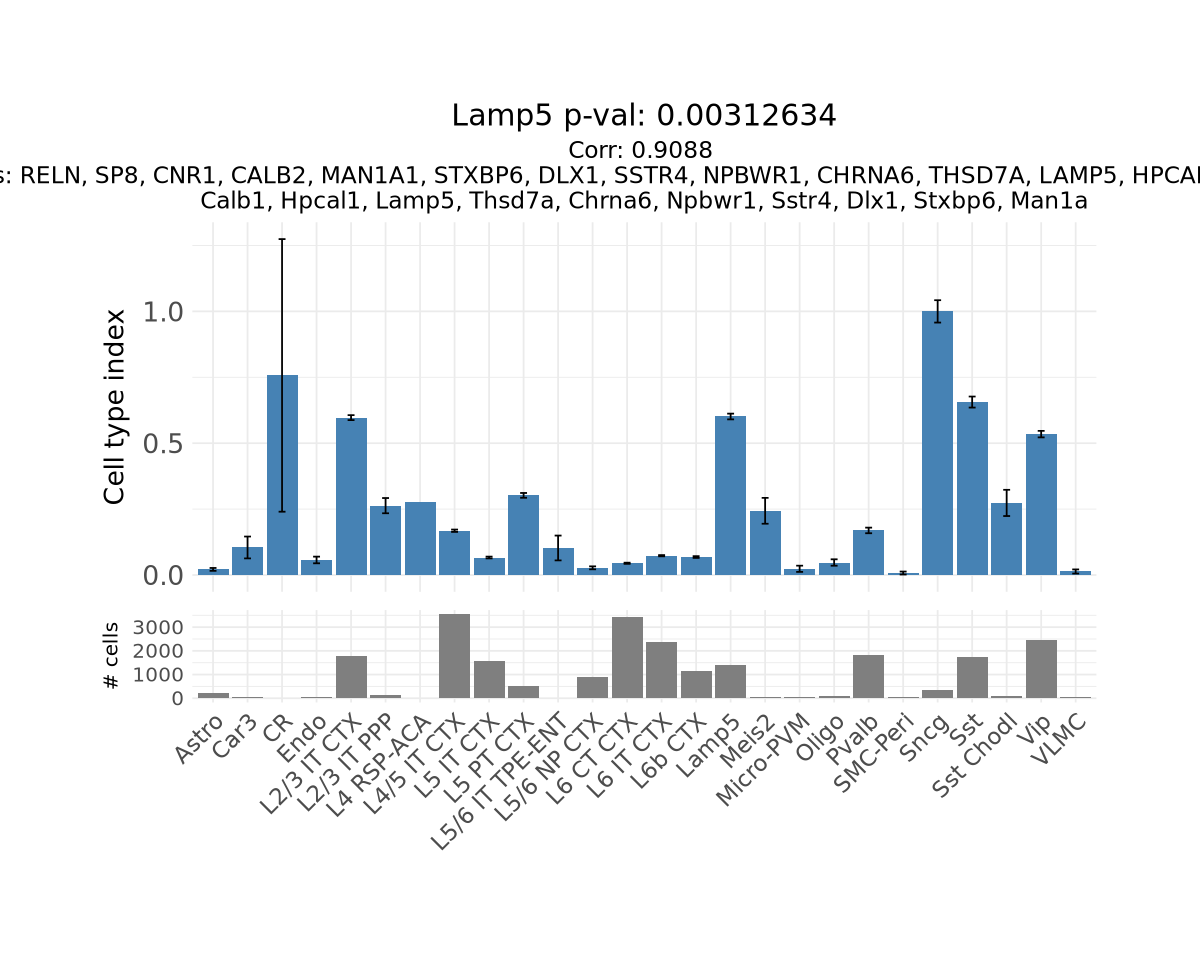

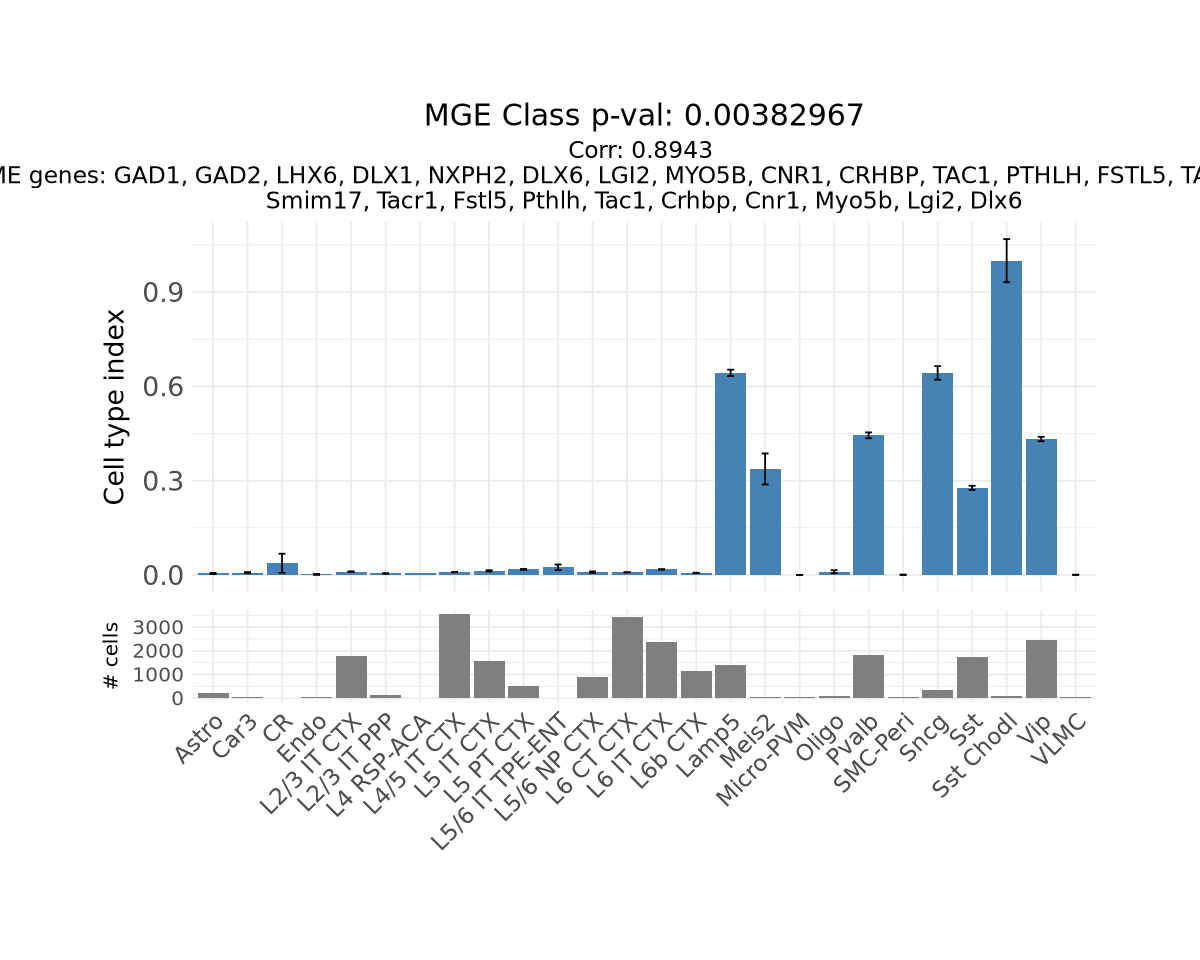

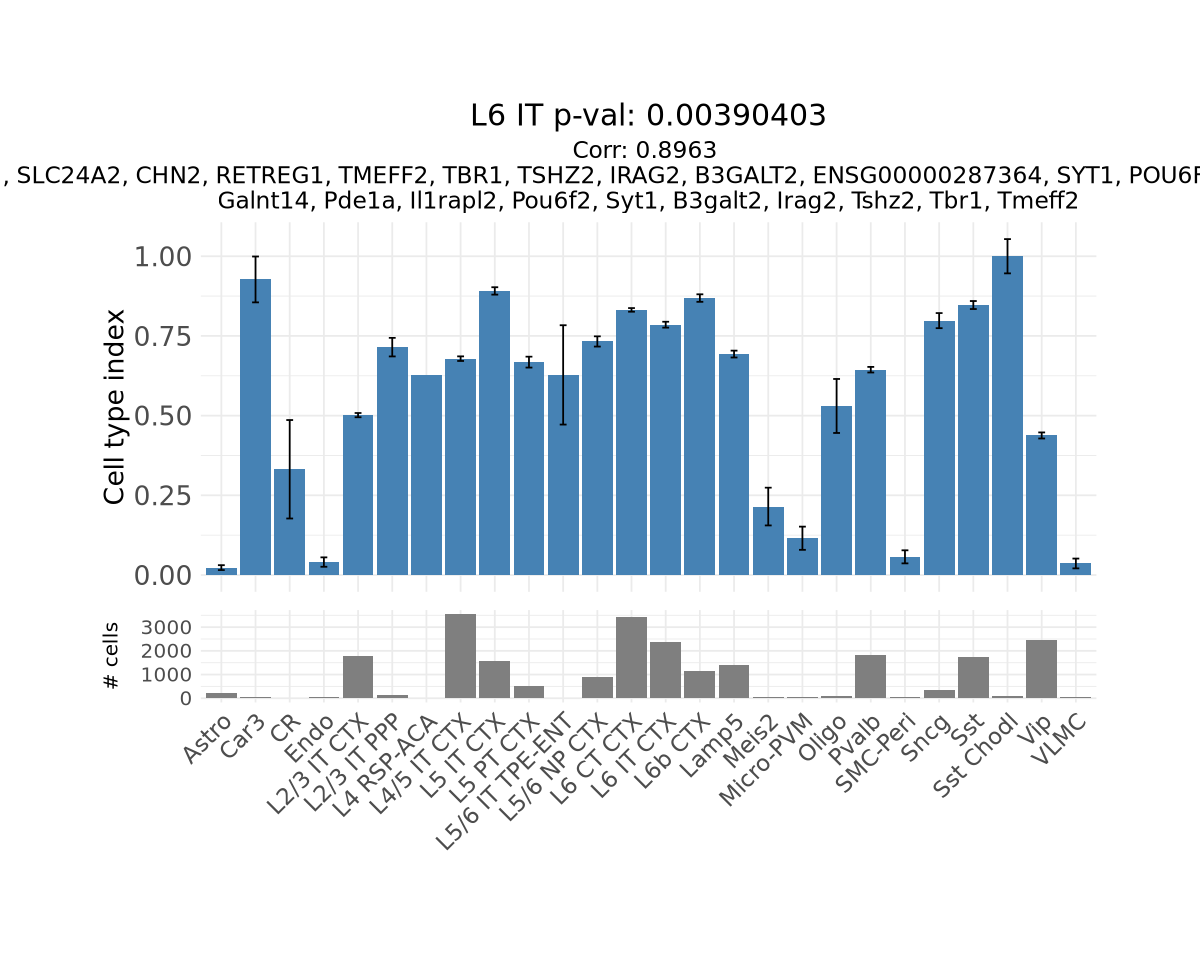

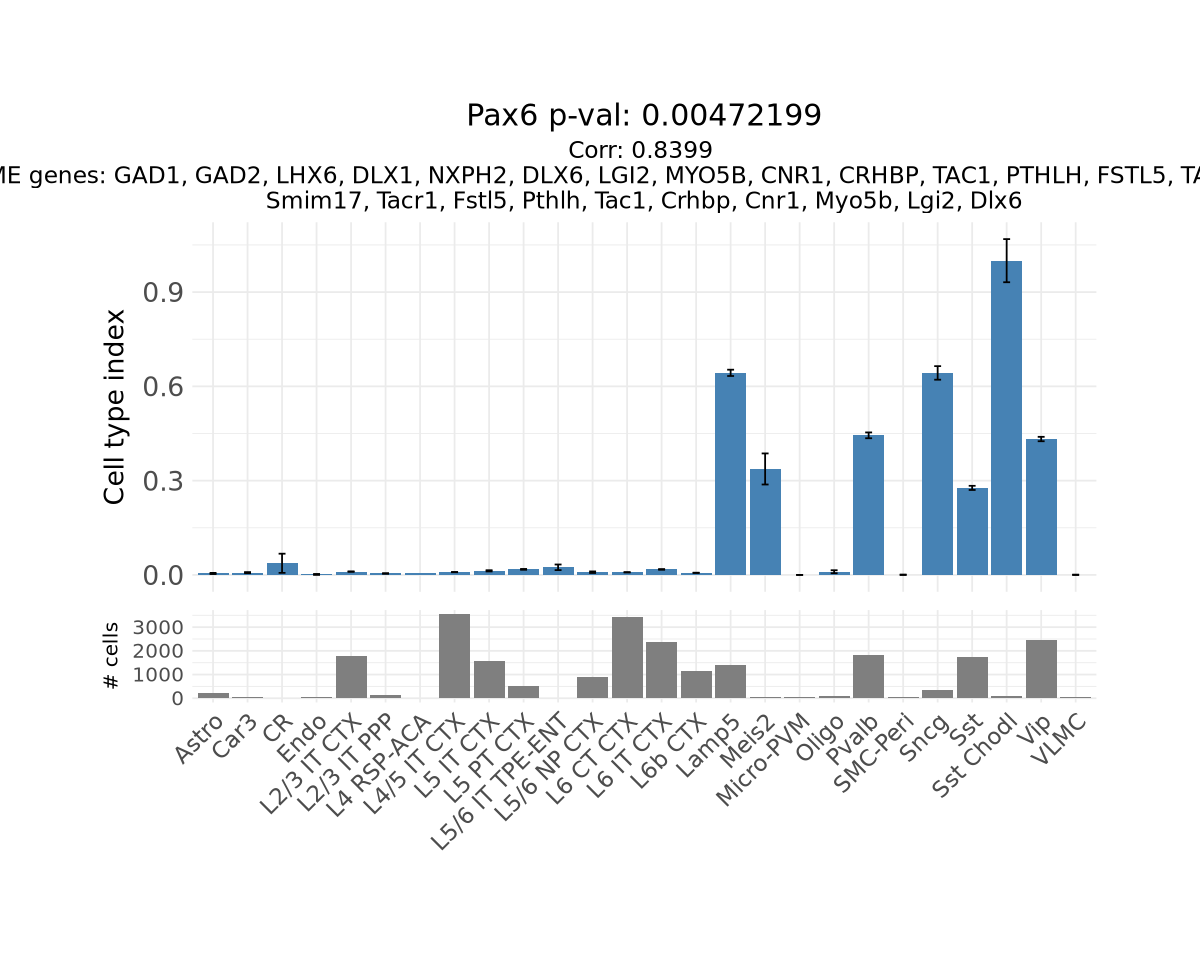

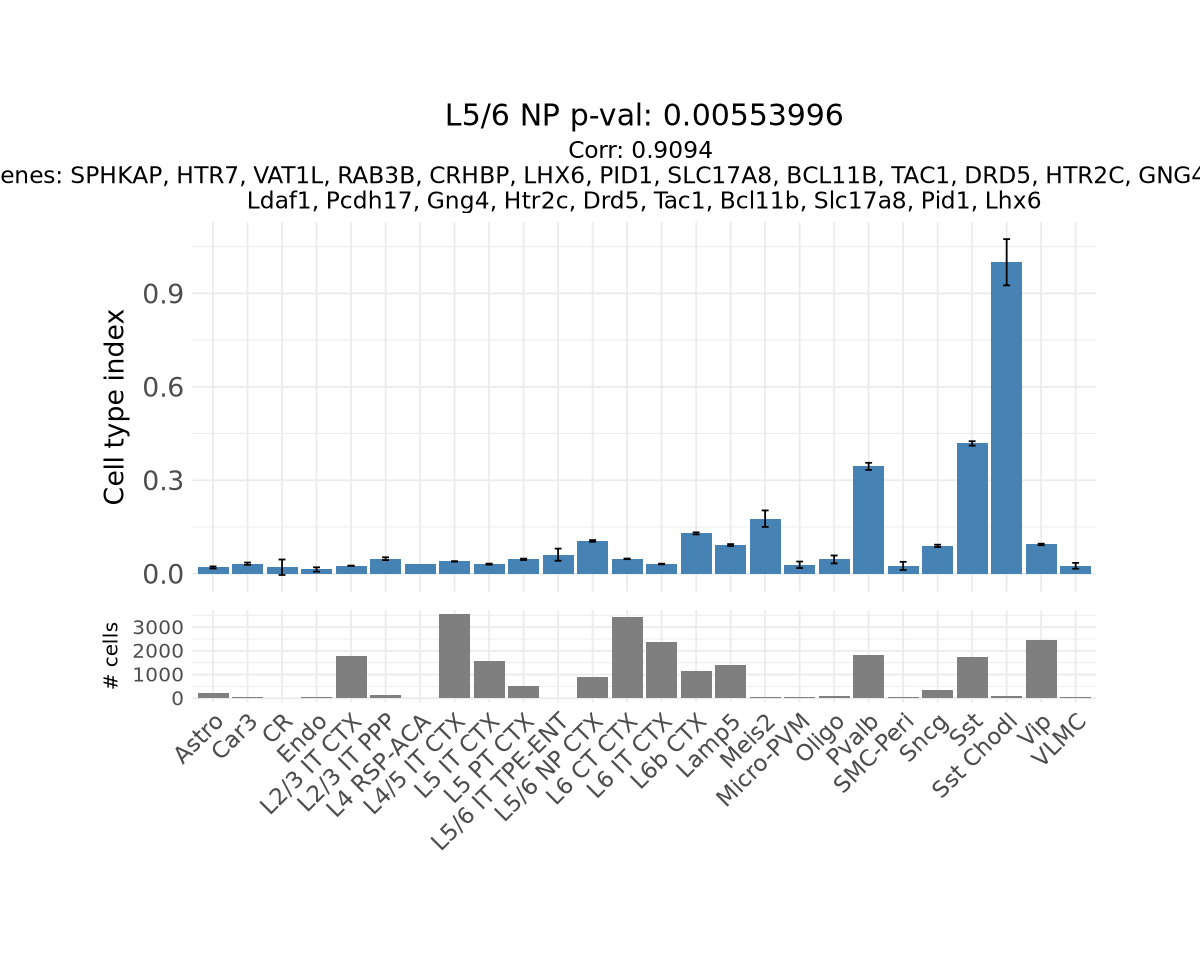

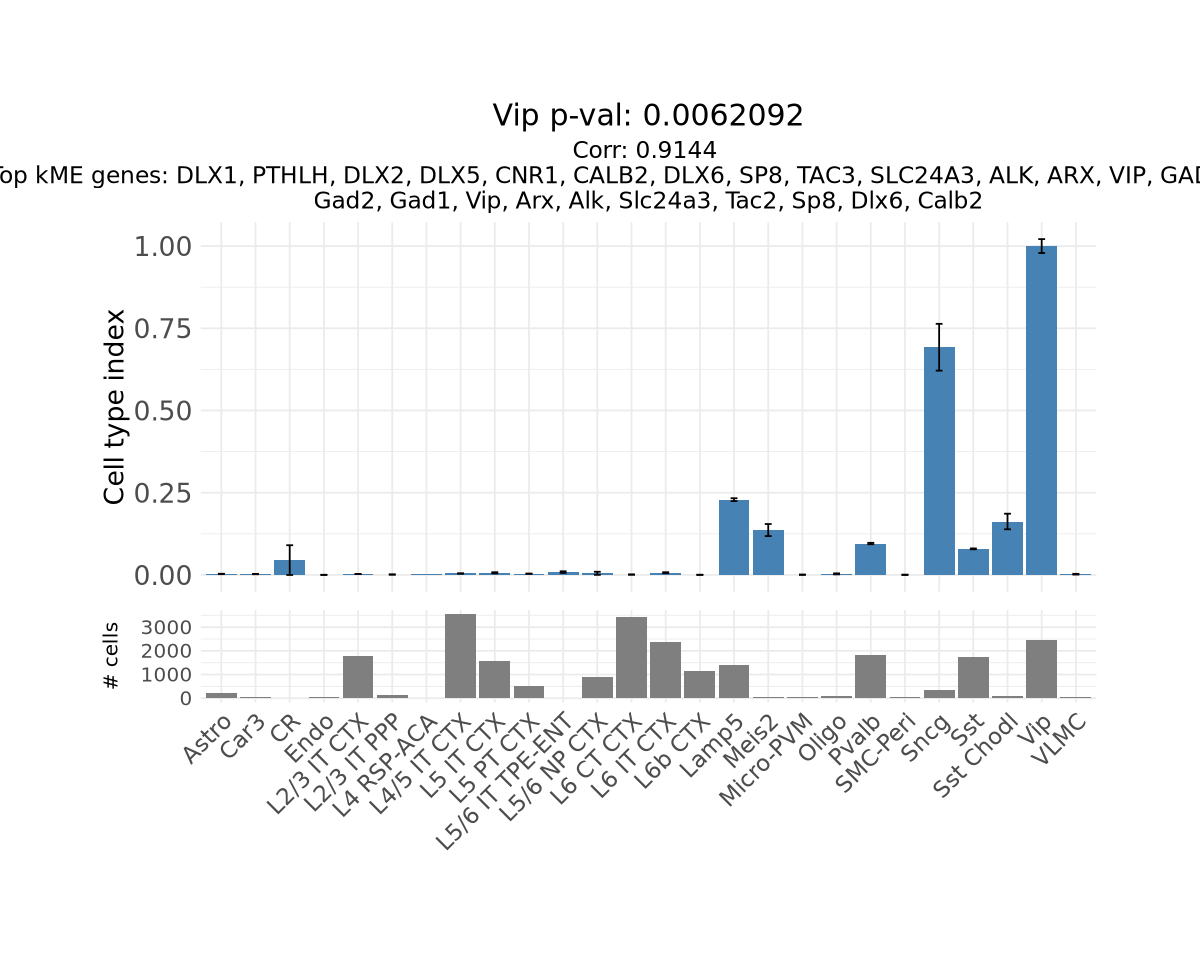

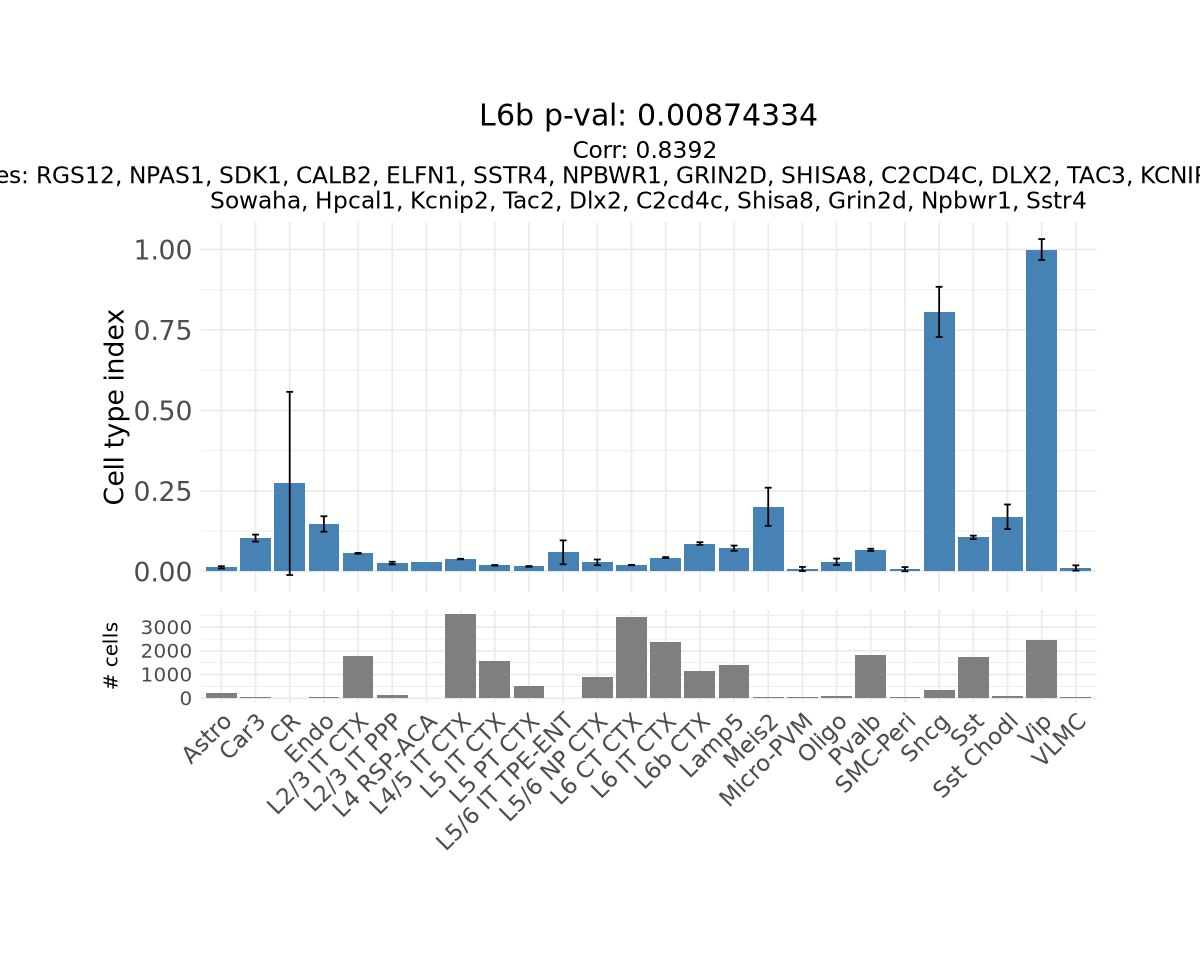

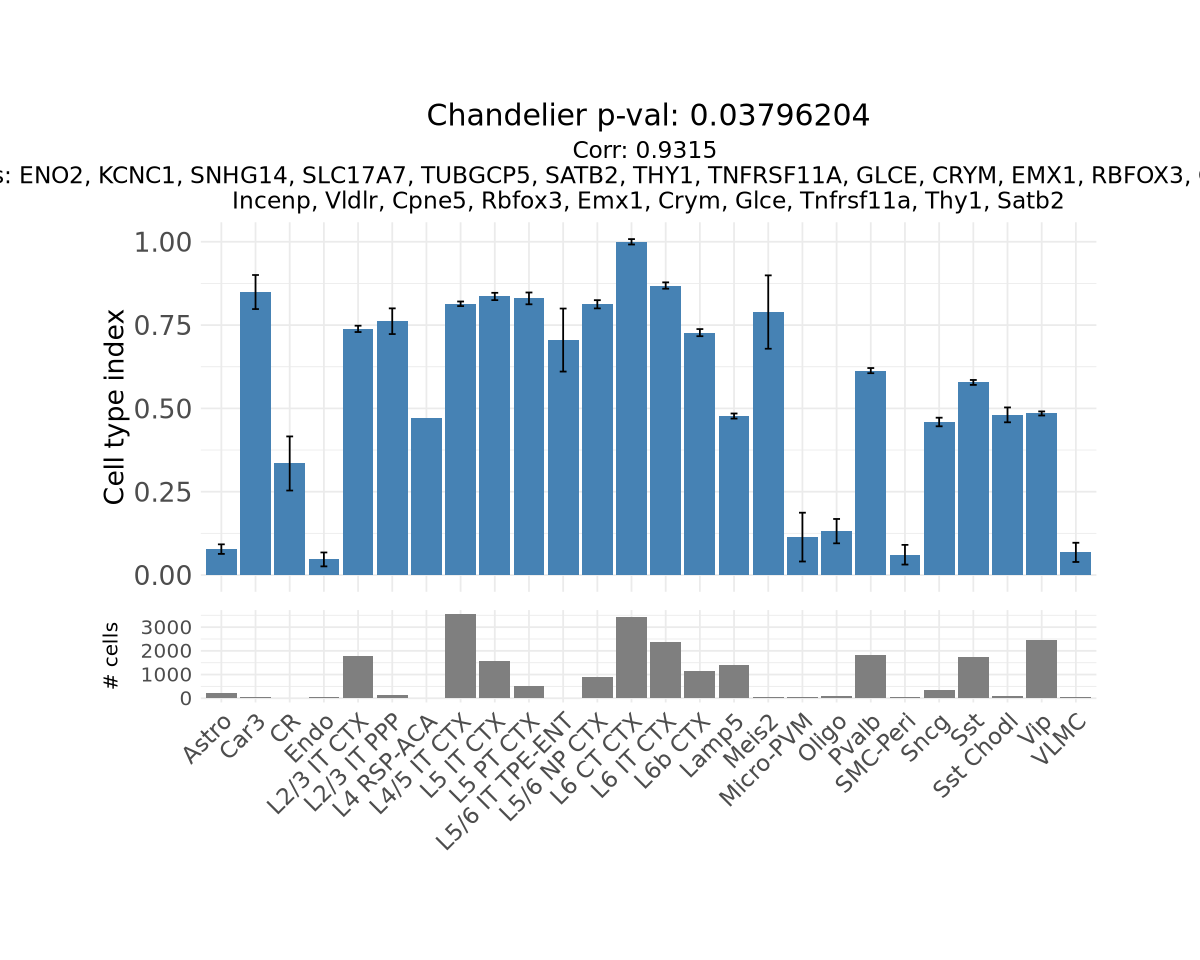

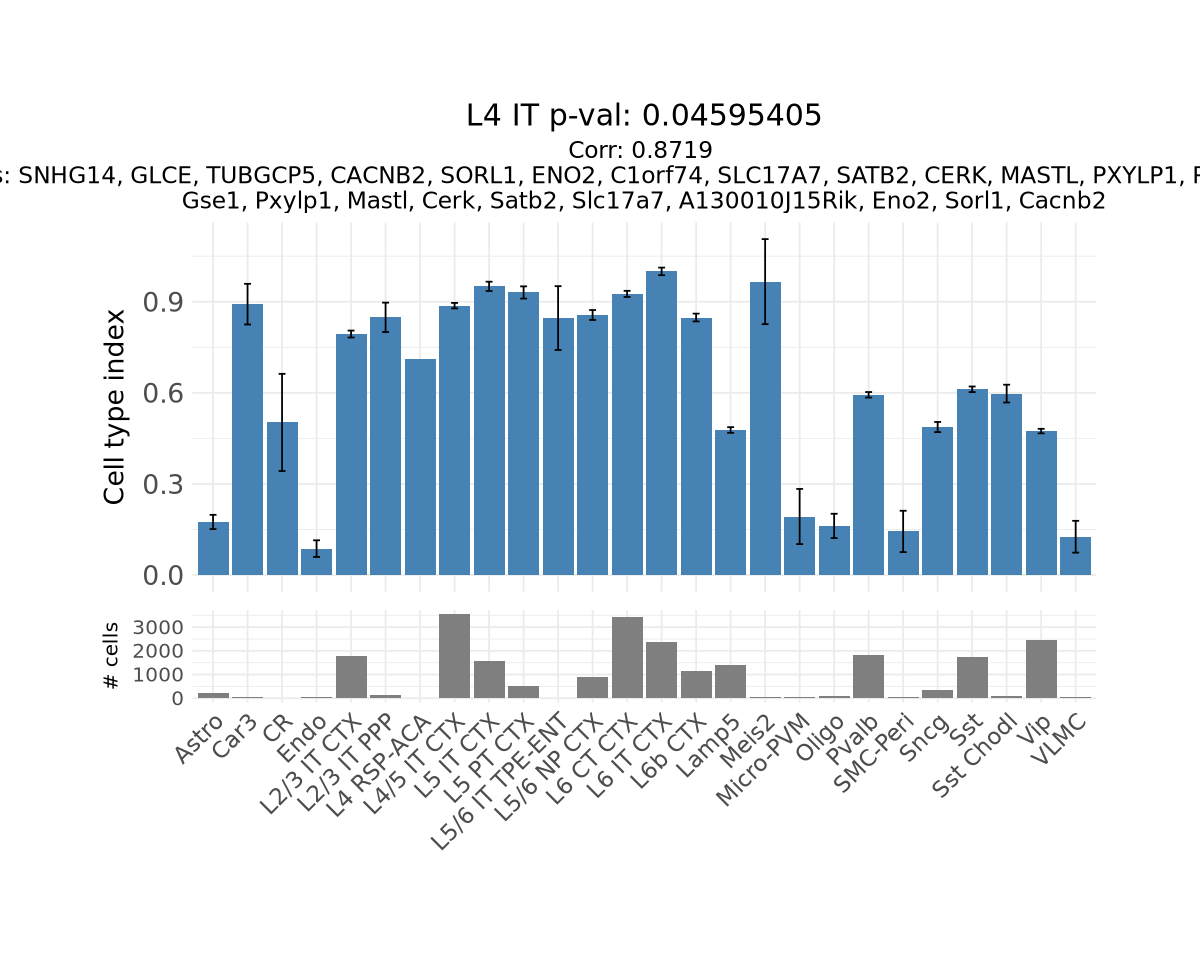

In [ ]:
# options(repr.plot.width=10, repr.plot.height=8)

# for(i in 1:nrow(top_mods_df)) {
#     gene_vec <- unlist(lapply(strsplit(top_mods_df$Top_kME_genes[i], ", "), "["))
#     plot_title <- paste(top_mods_df$Cell_type[i], "p-val:", round(top_mods_df$padj[i], 8))
#     plot_sub <- paste(
#         "Corr:", round(top_mods_df$Corr[i], 4), 
#         "\nTop kME genes:", top_mods_df$Top_kME_genes[i]
#     )
#     plot_gene_projections(sc_expr, gene_vec, ctype_assignment_vec, plot_title, plot_sub, target_species="mouse")   
# }